# Bayesian modelling of chocolate quality rating
#### Authors: Julia Wiktorowicz, Patrycja Wybranowska

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from cmdstanpy import CmdStanModel
import arviz as az
import matplotlib
import matplotlib.colors as mcolors

RELATIVE = False


## Data preprocessing
The raw data from Flavors of Cacao database contains information about producer and its origin country, country and details of bean origin, basic ingredients, most memorable characteristics, final rating and date of the review.



In [30]:
columns = [
    'REF', 'Company', 'Company Location', 'Review Date', 
    'Country of Bean Origin', 'Specific Bean Origin', 
    'Cocoa Percent', 'Ingredients', 'Most Memorable Characteristics', 'Rating'
]

df_pre = pd.read_csv('data/data.txt', sep='\t', names=columns, skiprows=1) if RELATIVE else pd.read_csv('/workspace/project2/Chocolate-DA/data/data.txt', sep='\t', names=columns, skiprows=1)
df_pre.head()

,REF,Company,Company Location,Review Date,Country of Bean Origin,Specific Bean Origin,Cocoa Percent,Ingredients,Most Memorable Characteristics,Rating
0,3016,Cacao Store,Japan,2026,Thailand,Chumphon,70%,"3- B,S,C","light apricot, pear, nutty, clean",3.25
1,3016,Cacao Store,Japan,2026,Taiwan,Fu-Wan,70%,"3- B,S,C","cocoa,roasty,pungent, chemical",2.75
2,3016,Cacao Store,Japan,2026,Madagascar,Ambanja,75%,"3- B,S,C","high acid, atypical honey",3.00
3,3016,URA,Peru,2026,Peru,"Piura, Chulucanas, Finca Tito Jimenez",70%,"3- B,S,C","grapes, roast (smoke like)",3.75
4,3020,URA,Peru,2026,Peru,"VRAEM 99, Pichari, Cusco, Finca Daria",70%,"3- B,S,C",plum,3.50


In [31]:
df = pd.read_csv('data/chocolate_data_preprocessed.csv') if RELATIVE else pd.read_csv('/workspace/project2/Chocolate-DA/data/chocolate_data_preprocessed.csv')
unique_ratings = sorted(df['Rating'].unique())
rating_map = {val: i + 1 for i, val in enumerate(unique_ratings)}
df['rating_id'] = df['Rating'].map(rating_map)
C = len(unique_ratings)
df.head()

,Company Location,Review Date,Country of Bean Origin,Cocoa Percent,Rating,Bean Origin ID,Company Location ID,Number of ingredients,Number of ingredients norm,Has vanilla,Year Norm,Cocoa Percent norm,rating_id
0,Japan,2026,Madagascar,75%,3.00,15,11,3.0,0.345818,0,2.447873,0.973354,4
1,Peru,2026,Peru,70%,3.75,18,15,3.0,0.345818,0,2.447873,-0.412919,7
2,Peru,2026,Peru,70%,3.50,18,15,3.0,0.345818,0,2.447873,-0.412919,6
3,U.K.,2026,Philippines,70%,3.50,19,19,3.0,0.345818,0,2.447873,-0.412919,6
4,Canada,2026,Peru,80%,3.25,18,5,3.0,0.345818,0,2.447873,2.359627,5


In [44]:
# All possible ratings from 1.0 to 5.0 in 0.25 steps
all_possible_ratings = [round(1.0 + 0.25 * i, 2) for i in range(17)]  # [1.0, 1.25, ..., 5.0]
rating_map = {val: i + 1 for i, val in enumerate(all_possible_ratings)}

df['rating_id'] = df['Rating'].map(rating_map)
C = 17  # hardcode, not len(unique_ratings)

print(df['rating_id'].value_counts().sort_index())
print(f"NaNs in rating_id: {df['rating_id'].isna().sum()}")  # should be 0
observed = set(df['rating_id'].unique())
all_ids = set(range(1, 18))
print("Missing rating categories:", sorted(all_ids - observed))

rating_id
6       3
7      54
8     113
9     248
10    223
11    276
12    118
13     41
Name: count, dtype: int64
NaNs in rating_id: 0
Missing rating categories: [1, 2, 3, 4, 5, 14, 15, 16, 17]


In [51]:
mis = [1, 2, 3, 4, 5, 14, 15, 16, 17]
mis = [float(x)*0.25 + 0.75 for x in mis]
print(mis)

[1.0, 1.25, 1.5, 1.75, 2.0, 4.25, 4.5, 4.75, 5.0]


### Prior predictive check

In [32]:
# prior_model1 = CmdStanModel(stan_file="prior_model1.stan") if RELATIVE else CmdStanModel(stan_file="/workspace/project2/Chocolate-DA/prior_model1.stan")
prior_model1 = CmdStanModel(stan_file="prior_model1_2.stan") if RELATIVE else CmdStanModel(stan_file="/workspace/project2/Chocolate-DA/prior_model1_2.stan")

J = df['Bean Origin ID'].max()
K = df['Company Location ID'].max()

prior_data1 = {
    "N": len(df),
    "J": J,
    "K": K,
    "C": C,
    "origin":  df['Bean Origin ID'].tolist(),       # Changed from "country"
    "producer": df['Company Location ID'].tolist(), # Changed from "location"
    "rating": df['rating_id'].tolist()
}

prior_fit1 = prior_model1.sample(
    data=prior_data1,
    fixed_param=True,
    iter_sampling=2000,
    chains=1,
    seed=42,
    show_progress=False,
)

rating_pred_prior1 = prior_fit1.stan_variable("rating_pred")
a_prior_draws1 = prior_fit1.stan_variable("alpha")
b_prior_draws1 = prior_fit1.stan_variable("gamma")
# mu_global_prior1 = prior_fit1.stan_variable("mu_global")
# sigma_prior_draws1  = prior_fit1.stan_variable("sigma")
sigma_origin_prior1   = prior_fit1.stan_variable("sigma_origin")
sigma_producer_prior1 = prior_fit1.stan_variable("sigma_producer")
c_prior_draws = prior_fit1.stan_variable("c")
sigma_origin_prior = prior_fit1.stan_variable("sigma_origin")
sigma_producer_prior = prior_fit1.stan_variable("sigma_producer")
alpha_prior = prior_fit1.stan_variable("alpha")

20:26:41 - cmdstanpy - INFO - CmdStan start processing
20:26:41 - cmdstanpy - INFO - Chain [1] start processing
20:26:43 - cmdstanpy - INFO - Chain [1] done processing


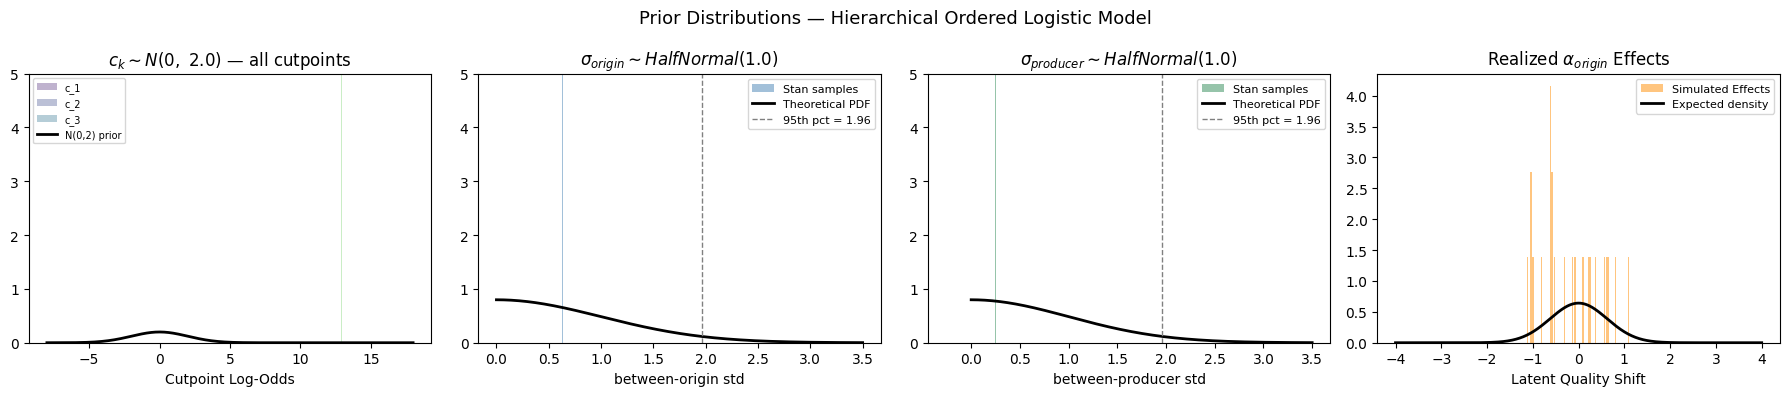

In [33]:
x_sigma = np.linspace(0, 3.5, 500)
x_c     = np.linspace(-8, 18, 500)
x_alpha = np.linspace(-4, 4, 500)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# --- Panel 1: all cutpoints overlaid, one color per cutpoint ---
C_minus_1 = c_prior_draws.shape[1]   # 7 in your case
colors_c = plt.cm.viridis(np.linspace(0.1, 0.9, C_minus_1))
for k in range(C_minus_1):
    axes[0].hist(c_prior_draws[:, k], bins=60, density=True, alpha=0.35,
                 color=colors_c[k], label=f"c_{k+1}" if k < 3 else None)
axes[0].plot(x_c, stats.norm.pdf(x_c, 0, 2), lw=2, color='black', label="N(0,2) prior")
axes[0].set_title(r"$c_k \sim N(0,\ 2.0)$ — all cutpoints")
axes[0].set_xlabel("Cutpoint Log-Odds")
axes[0].set_ylim([0, 5])
axes[0].legend(fontsize=7)

# --- Panel 2: sigma_origin ---
axes[1].hist(sigma_origin_prior, bins=60, density=True, alpha=0.5,
             color='steelblue', label="Stan samples")
axes[1].plot(x_sigma, 2*stats.norm.pdf(x_sigma, 0, 1), lw=2, color='black',
             label="Theoretical PDF")
axes[1].axvline(stats.halfnorm.ppf(0.95, scale=1.0), color="gray", ls="--", lw=1,
                label=f"95th pct = {stats.halfnorm.ppf(0.95, scale=1.0):.2f}")
axes[1].set_title(r"$\sigma_{origin} \sim HalfNormal(1.0)$")
axes[1].set_xlabel("between-origin std")
axes[1].set_ylim([0, 5])

axes[1].legend(fontsize=8)

# --- Panel 3: sigma_producer ---
axes[2].hist(sigma_producer_prior, bins=60, density=True, alpha=0.5,
             color='seagreen', label="Stan samples")
axes[2].plot(x_sigma, 2*stats.norm.pdf(x_sigma, 0, 1), lw=2, color='black',
             label="Theoretical PDF")
axes[2].axvline(stats.halfnorm.ppf(0.95, scale=1.0), color="gray", ls="--", lw=1,
                label=f"95th pct = {stats.halfnorm.ppf(0.95, scale=1.0):.2f}")
axes[2].set_title(r"$\sigma_{producer} \sim HalfNormal(1.0)$")
axes[2].set_ylim([0, 5])
axes[2].set_xlabel("between-producer std")
axes[2].legend(fontsize=8)

# --- Panel 4: realized alpha effects ---
axes[3].hist(alpha_prior.flatten(), bins=80, density=True, alpha=0.5,
             color='darkorange', label="Simulated Effects")
axes[3].plot(x_alpha,
             np.mean([stats.norm.pdf(x_alpha, 0, s) for s in sigma_origin_prior], axis=0),
             lw=2, color='black', label="Expected density")
axes[3].set_title(r"Realized $\alpha_{origin}$ Effects")
axes[3].set_xlabel("Latent Quality Shift")
axes[3].legend(fontsize=8)

plt.suptitle("Prior Distributions — Hierarchical Ordered Logistic Model", fontsize=13)
plt.tight_layout()
plt.show()

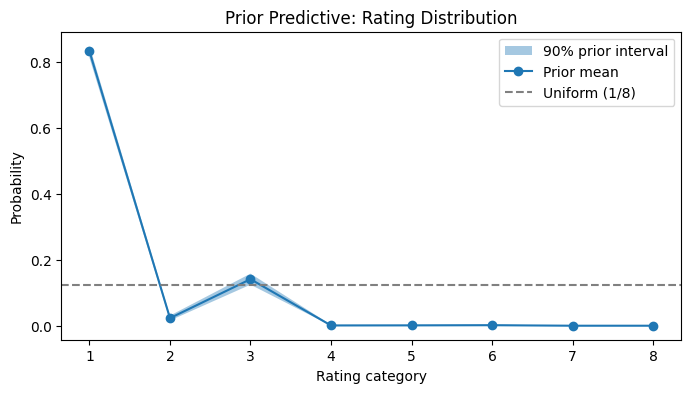

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
# rating_pred shape: (n_draws, N) — average over observations
pred_counts = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C), 1, rating_pred_prior1
)
pred_probs = pred_counts / pred_counts.sum(axis=1, keepdims=True)

ax.fill_between(
    range(1, C+1),
    np.percentile(pred_probs, 5, axis=0),
    np.percentile(pred_probs, 95, axis=0),
    alpha=0.4, label="90% prior interval"
)
ax.plot(range(1, C+1), pred_probs.mean(axis=0), marker='o', label="Prior mean")
ax.axhline(1/C, ls='--', color='gray', label=f"Uniform (1/{C})")
ax.set_xlabel("Rating category"); ax.set_ylabel("Probability")
ax.set_title("Prior Predictive: Rating Distribution")
ax.legend()

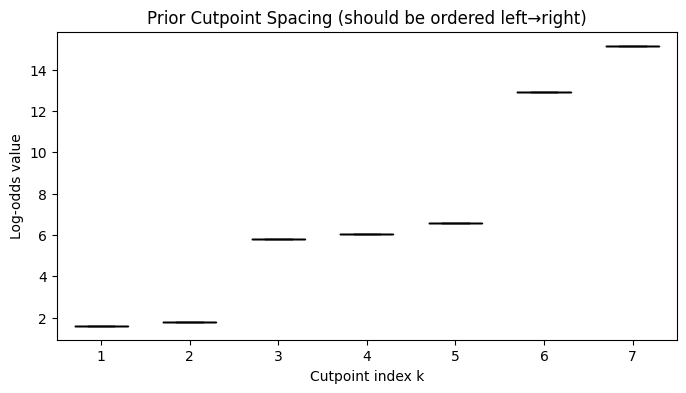

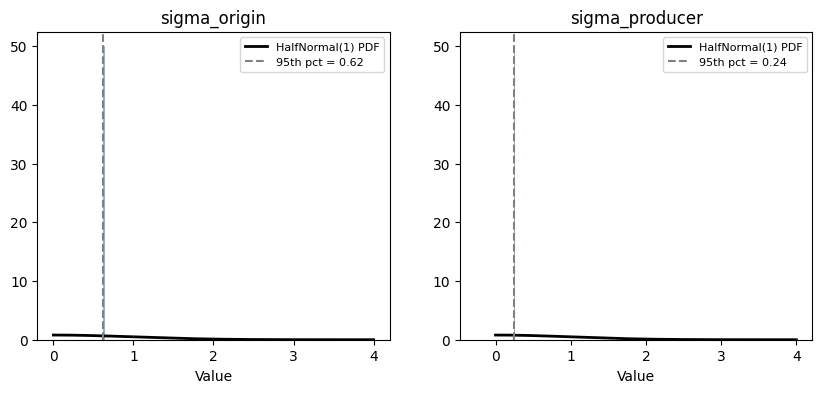

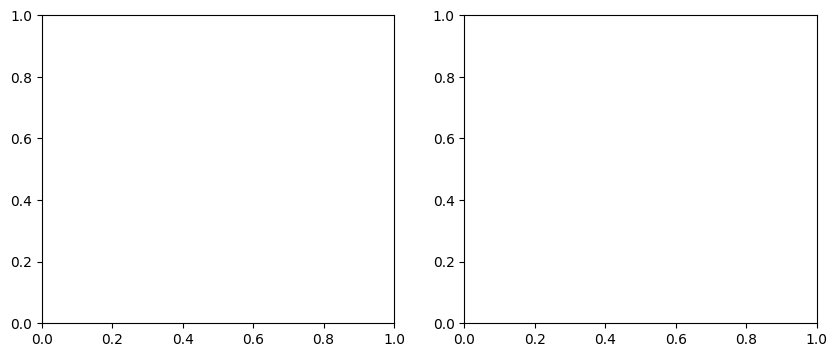

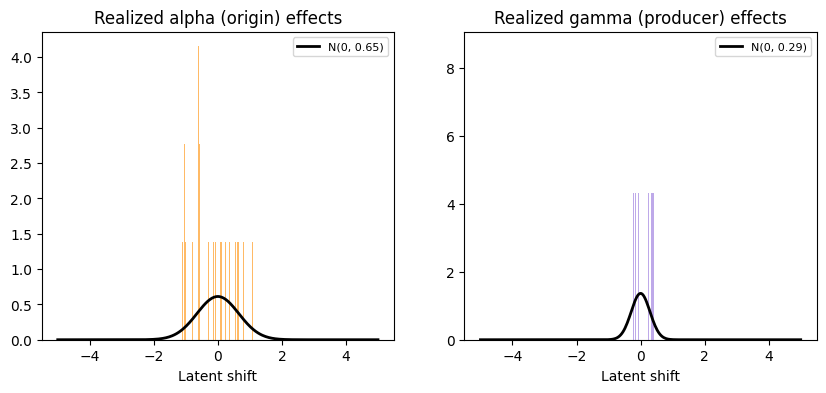

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
for k in range(C - 1):
    ax.boxplot(c_prior_draws[:, k], positions=[k+1], widths=0.6,
               medianprops=dict(color='black'))
ax.set_xlabel("Cutpoint index k")
ax.set_ylabel("Log-odds value")
ax.set_title("Prior Cutpoint Spacing (should be ordered left→right)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.linspace(0, 4, 300)
ref = stats.halfnorm.pdf(x, scale=1.0)

for ax, samples, name, color in zip(
    axes,
    [sigma_origin_prior, sigma_producer_prior],
    ["sigma_origin", "sigma_producer"],
    ["steelblue", "seagreen"]
):
    ax.hist(samples, bins=50, density=True, alpha=0.6, color=color)
    ax.plot(x, ref, 'k-', lw=2, label="HalfNormal(1) PDF")
    ax.axvline(np.percentile(samples, 95), ls='--', color='gray',
               label=f"95th pct = {np.percentile(samples,95):.2f}")
    ax.set_title(f"{name}")
    ax.set_xlabel("Value"); ax.legend(fontsize=8)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, draws, name, color in zip(
    axes, [a_prior_draws1, b_prior_draws1],
    ["alpha (origin)", "gamma (producer)"], ["darkorange", "mediumpurple"]
):
    ax.hist(draws.flatten(), bins=80, density=True, alpha=0.6, color=color)
    # overlay a N(0, median_sigma) reference
    med_sigma = np.median(draws.std(axis=1))
    x = np.linspace(-5, 5, 300)
    ax.plot(x, stats.norm.pdf(x, 0, med_sigma), 'k-', lw=2,
            label=f"N(0, {med_sigma:.2f})")
    ax.set_title(f"Realized {name} effects")
    ax.set_xlabel("Latent shift"); ax.legend(fontsize=8)

In [36]:
print("c shape:", c_prior_draws.shape)
print("sigma_origin shape:", sigma_origin_prior.shape)
print("sigma_producer shape:", sigma_producer_prior.shape)
print("alpha shape:", alpha_prior.shape)

c shape: (2000, 7)
sigma_origin shape: (2000,)
sigma_producer shape: (2000,)
alpha shape: (2000, 26)


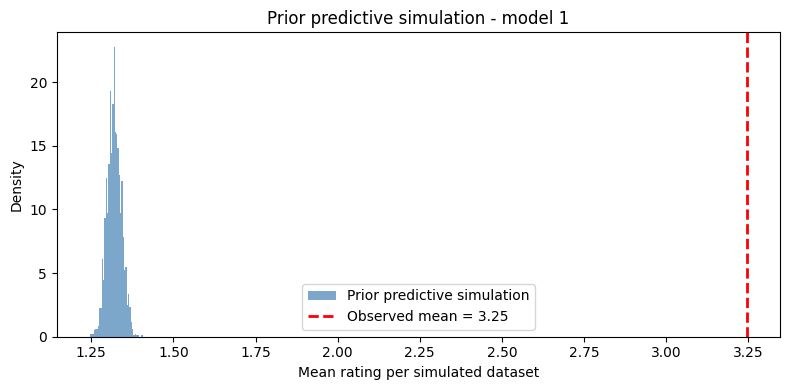

In [37]:
prior_draw_means1 = rating_pred_prior1.mean(axis=1)
observed_mean     = df["Rating"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_draw_means1, bins=40, density=True, alpha=0.7,
        color="steelblue", label="Prior predictive simulation")
ax.axvline(observed_mean, color="red", lw=2, ls="--",
           label=f"Observed mean = {observed_mean:.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Prior predictive simulation - model 1")
ax.legend()
plt.tight_layout()
plt.show()

Predicted average chocolate ratings are bounded between 1.5 and 4.5 proving that the model respects rating limits 1-5. The observed dataset mean falls within high density region of the prior predictive distribution, confirming that our priors are well-calibrated.

### Posterior analysis

```stan
data {
  int<lower=1> N;
  int<lower=1> J;
  int<lower=1> K;
  array[N] int<lower=1, upper=J> country;
  array[N] int<lower=1, upper=K> location;
  vector[N] rating;
}
parameters {
  real mu_global;
  vector[J] a_raw;
  vector[K] b_raw;
  real<lower=1e-6> sigma_origin;
  real<lower=1e-6> sigma_producer;
  real<lower=1e-6> sigma;
}
transformed parameters {
  vector[J] a = a_raw * sigma_origin;
  vector[K] b = b_raw * sigma_producer;
}
model {
  mu_global      ~ normal(3, 0.5);
  sigma_origin   ~ normal(0, 0.3);
  sigma_producer ~ normal(0, 0.3);
  sigma          ~ exponential(2);

  a_raw ~ std_normal();
  b_raw ~ std_normal();

  for (i in 1:N)
    rating[i] ~ normal(mu_global + a[country[i]] + b[location[i]], sigma);
}
generated quantities {
  array[N] real rating_pred;
  array[N] real log_lik;
  for (i in 1:N) {
    rating_pred[i] = normal_rng(mu_global + a[country[i]] + b[location[i]], sigma);
    log_lik[i] = normal_lpdf(rating[i] | mu_global + a[country[i]] + b[location[i]], sigma);
  }
}
```

In [38]:
model_1_fit = CmdStanModel(stan_file="model_1.stan")

data_sim1 = {
    "N":        len(df),
    "J":        J,
    "K":        K,
    "country":  df['Bean Origin ID'].tolist(),
    "location": df['Company Location ID'].tolist(),
    "rating":   df["Rating"].tolist(),
}

fit1 = model_1_fit.sample(
    data=data_sim1,
    seed=42,
    chains=4,
    show_progress=False,
)

print(fit1.summary())
print(fit1.diagnose())

rating_pred_post1  = fit1.stan_variable("rating_pred")
a_samples1  = fit1.stan_variable("a")
b_samples1 = fit1.stan_variable("b")
sigma_samples1 = fit1.stan_variable("sigma")
mu_global_samples1 = fit1.stan_variable("mu_global")

ValueError: no such file /workspace/model_1.stan

Non-fatal warnings occured at the start of the warmup phase but they did not affect the validity of the final posterior draws. The MCMC sampling process was completed successfully with no problems detected. The R_hat values for all parameters are smaller than 1.01 indicating optimal chain convergence. 

NameError: name 'mu_global_prior1' is not defined

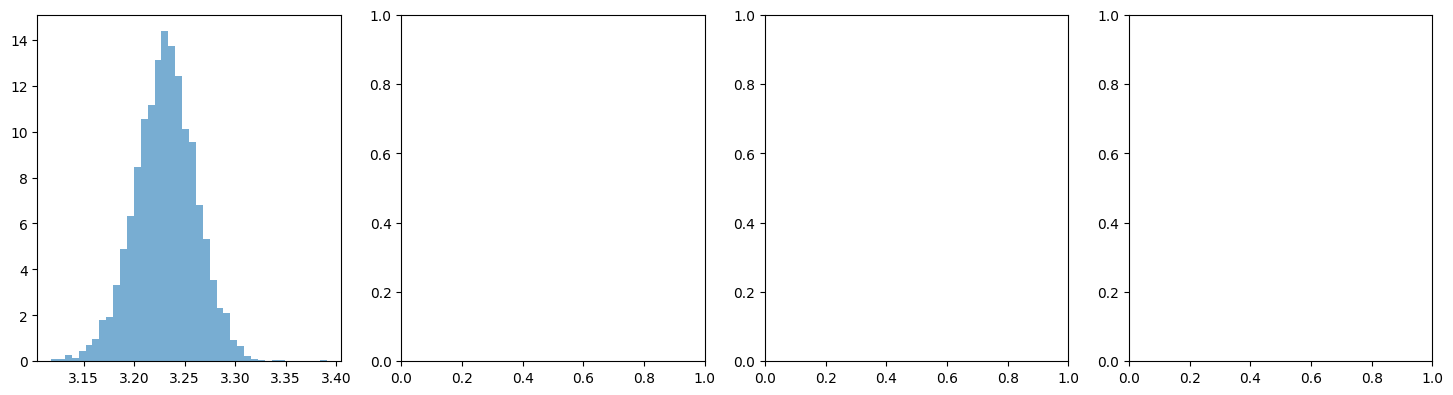

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

axes[0].hist(mu_global_samples1, bins=40, density=True, alpha=0.6, label="Posterior")
axes[0].hist(mu_global_prior1, bins=100, density=True, alpha=0.4, color="gray", label="Prior")
axes[0].set_title(r"$\mu_{global}$")
axes[0].set_xlim(1, 5) 
axes[0].set_xlabel(r"Global mean parameter value")
axes[0].set_ylabel("Density")
axes[0].legend(loc="upper right", fontsize=9)

axes[1].hist(a_samples1.flatten(), bins=80, density=True, alpha=0.6, label="Posterior")
axes[1].hist(a_prior_draws1.flatten(), bins=200, density=True, alpha=0.4, color="gray", label="Prior")
axes[1].set_title(r"$a$ (origin effect)")
axes[1].set_xlim(-0.75, 0.75) 
axes[1].set_xlabel("Origin group effect value")
axes[1].legend(loc="upper right", fontsize=9)

axes[2].hist(b_samples1.flatten(), bins=80, density=True, alpha=0.6, label="Posterior")
axes[2].hist(b_prior_draws1.flatten(), bins=200, density=True, alpha=0.4, color="gray", label="Prior")
axes[2].set_title(r"$b$ (producer effect)")
axes[2].set_xlim(-1, 1) 
axes[2].set_xlabel("Producer group effect value")
axes[2].legend(loc="upper right", fontsize=9)

axes[3].hist(sigma_samples1, bins=40, density=True, alpha=0.6, label="Posterior")
axes[3].hist(sigma_prior_draws1, bins=150, density=True, alpha=0.4, color="gray", label="Prior")
axes[3].set_title(r"$\sigma$")
axes[3].set_xlim(0.0, 1.0) 
axes[3].set_xlabel(r"Residual std value")
axes[3].legend(loc="upper right", fontsize=9)

plt.suptitle("Posterior vs prior", fontsize=13)
plt.tight_layout()
plt.show()

The posterior distribution narrowed significantly compared to their more flat priors. The global intercept $\mu_{global}$ and observation level noise $\sigma$ display highly symmetric and concentrated distributions compared to their priors. Both group effects are concentrated around zero indicating no global bias in the grouping variables. The producer effect (*b*) exhibits noticeably wider distribution with lower peak compared to the country of bean origin effect (*a*). This confirms that individual manufacturer approach to crafting chocolate may introduce grater variability to the final chocolate ratings than bean origin.

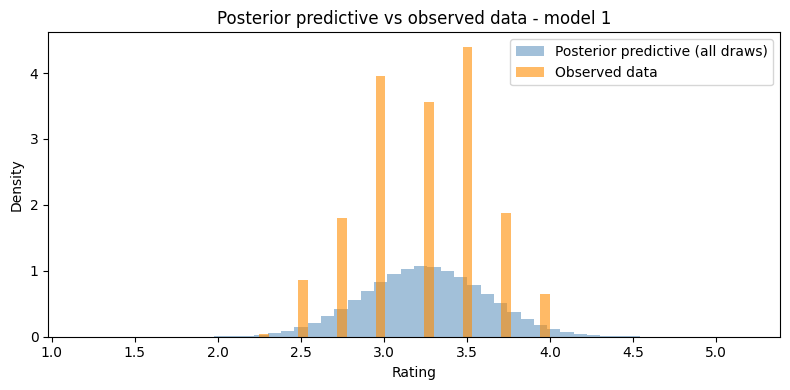

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rating_pred_post1.flatten(), bins=50, density=True, alpha=0.5,
        color="steelblue", label="Posterior predictive (all draws)")
ax.hist(df["Rating"], bins=30, density=True, alpha=0.6,
        color="darkorange", label="Observed data")
ax.set_xlabel("Rating")
ax.set_ylabel("Density")
ax.set_title("Posterior predictive vs observed data - model 1")
ax.legend()
plt.tight_layout()
plt.show()


Posterior predictive distribution successfully replicates the overall location and spread of the observed data.

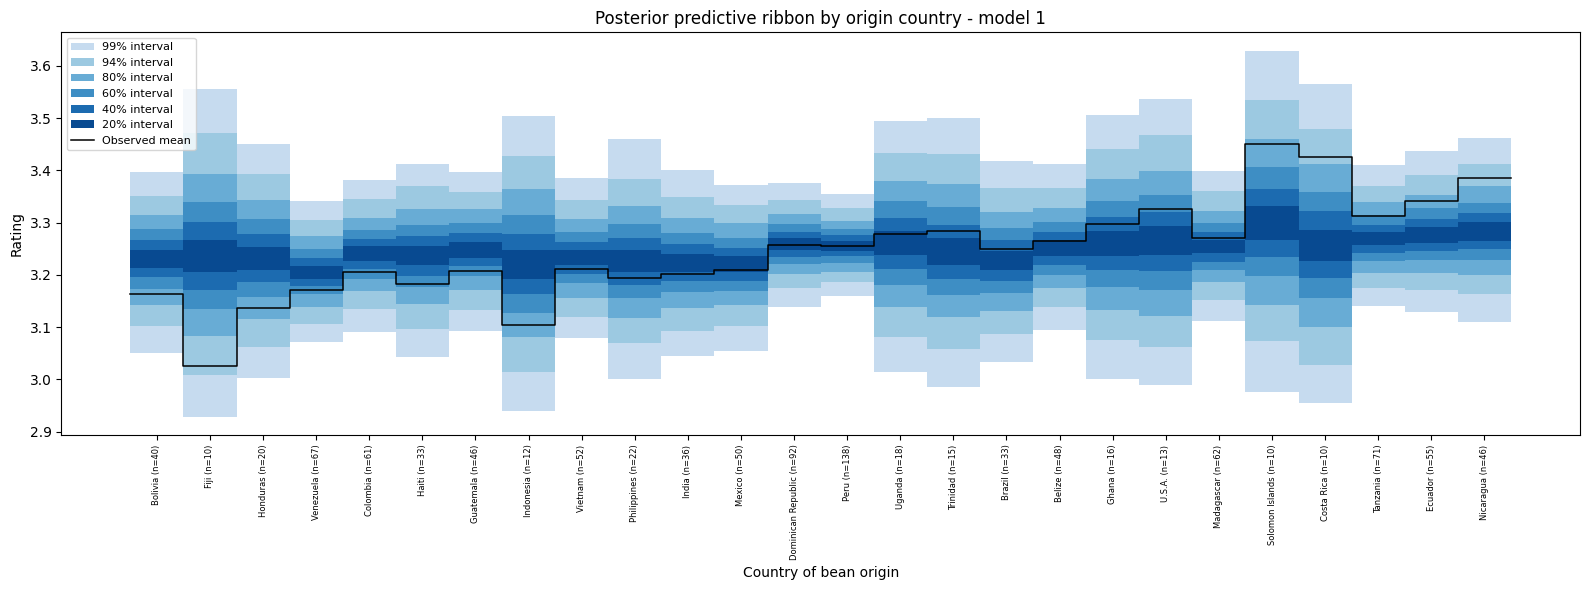

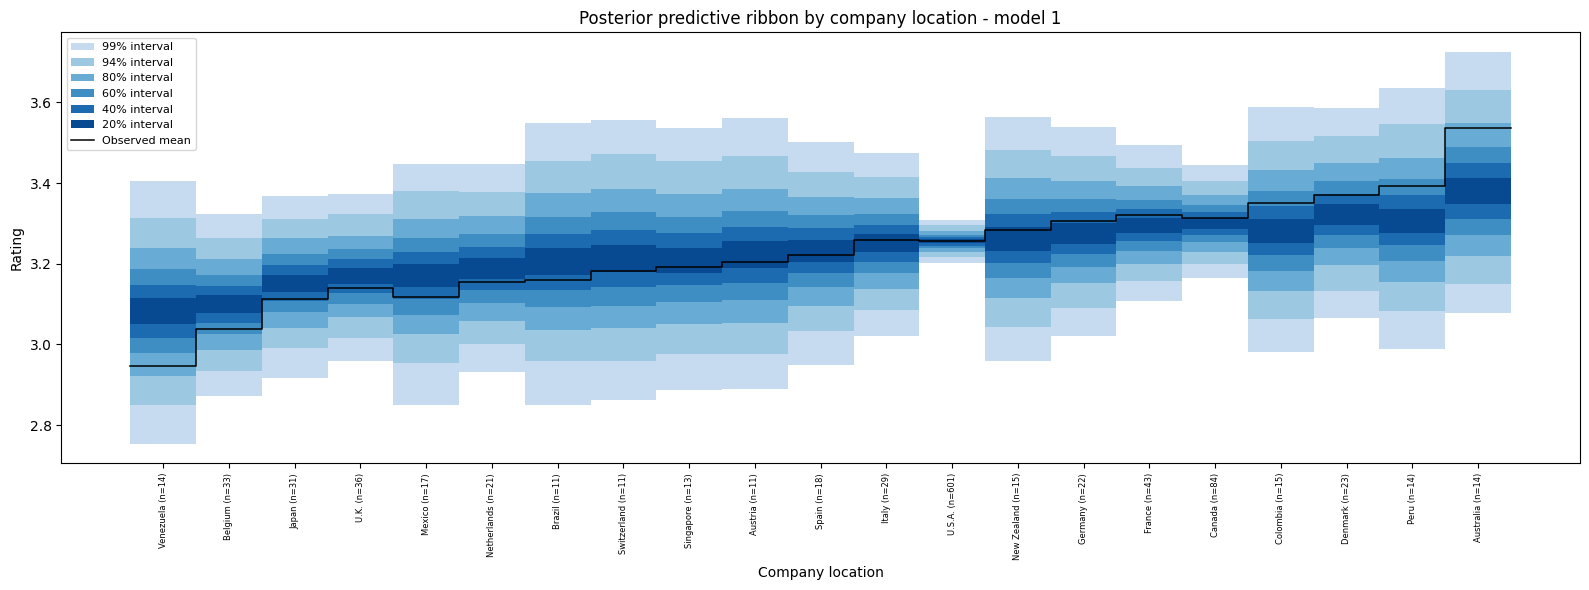

In [ ]:
mu_country_total1 = mu_global_samples1[:, None] + a_samples1
current_df = df.copy().reset_index(drop=True)
countries = sorted(current_df["Country of Bean Origin"].unique())
country_idx = {c: i + 1 for i, c in enumerate(countries)}
current_df["country_id"] = current_df["Country of Bean Origin"].map(country_idx)
counts_origin = current_df["Country of Bean Origin"].value_counts().to_dict()

results11 = pd.DataFrame({
    "country":     countries,
    "mu_mean":     mu_country_total1.mean(axis=0),
    "mu_lower_94": np.percentile(mu_country_total1, 3, axis=0),
    "mu_upper_94": np.percentile(mu_country_total1, 97, axis=0),
    "n_bars":      [counts_origin.get(c, 0) for c in countries],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

observed_per_country1 = current_df.groupby("country_id")["Rating"].mean()
obs_sorted1 = results11["country"].map(
    lambda c: observed_per_country1[country_idx[c]]
).values

num_samples1 = rating_pred_post1.shape[0]
J_sorted1 = len(results11)
x2 = np.arange(1, J_sorted1 + 1)

post_pred_means_sorted2 = np.zeros((num_samples1, J_sorted1))
for i, country_name in enumerate(results11["country"]):
    country_id_val = country_idx[country_name]
    obs_indices = current_df[current_df["country_id"] == country_id_val].index.values
    post_pred_means_sorted2[:, i] = rating_pred_post1[:, obs_indices].mean(axis=1)

levels = [99, 94, 80, 60, 40, 20]
bands2 = {}
for lev in levels:
    lo = (100 - lev) / 2
    hi = 100 - lo
    bands2[lev] = (
        np.percentile(post_pred_means_sorted2, lo, axis=0),
        np.percentile(post_pred_means_sorted2, hi, axis=0),
    )

def step_edges(values, x):
    edges = np.concatenate([x - 0.5, x[-1:] + 0.5])
    stepped = np.concatenate([[values[0]], values])
    return edges, stepped

cmap = matplotlib.colormaps["Blues"]
fracs = np.linspace(0.25, 0.9, len(levels))
colors = [mcolors.to_hex(cmap(f)) for f in fracs]

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo, hi = bands2[lev]
    edges_lo, lo_step = step_edges(lo, x2)
    _, hi_step = step_edges(hi, x2)
    ax.fill_between(edges_lo, lo_step, hi_step, step="pre",
                    color=color, linewidth=0, label=f"{lev}% interval")

edges_obs2, obs_step2 = step_edges(obs_sorted1, x2)
ax.step(edges_obs2, obs_step2, where="pre", color="black",
        linewidth=1.1, label="Observed mean")

ax.set_xticks(x2)
ax.set_xticklabels(
    [f"{r['country']} (n={r['n_bars']})" for _, r in results11.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Country of bean origin")
ax.set_ylabel("Rating")
ax.set_title("Posterior predictive ribbon by origin country - model 1")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

#  --------------------------

mu_company_total1 = mu_global_samples1[:, None] + b_samples1
current_df = df.copy().reset_index(drop=True)
company_locations = sorted(current_df["Company Location"].unique())
company_idx = {c: i + 1 for i, c in enumerate(company_locations)}
current_df["company_id"] = current_df["Company Location"].map(company_idx)
counts_company = current_df["Company Location"].value_counts().to_dict()

results12 = pd.DataFrame({
    "company":     company_locations,
    "mu_mean":     mu_company_total1.mean(axis=0),
    "mu_lower_94": np.percentile(mu_company_total1, 3, axis=0),
    "mu_upper_94": np.percentile(mu_company_total1, 97, axis=0),
    "n_bars":      [counts_company.get(c, 0) for c in company_locations],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)
# results12 = results12[results12["n_bars"] >= 10].reset_index(drop=True)
observed_per_company1 = current_df.groupby("company_id")["Rating"].mean()
obs_sorted1 = results12["company"].map(
    lambda c: observed_per_company1[company_idx[c]]
).values

num_samples1 = rating_pred_post1.shape[0]
J_sorted1 = len(results12)
x2 = np.arange(1, J_sorted1 + 1)

post_pred_means_sorted2 = np.zeros((num_samples1, J_sorted1))
for i, company_name in enumerate(results12["company"]):
    company_id_val = company_idx[company_name]
    obs_indices = current_df[current_df["company_id"] == company_id_val].index.values
    post_pred_means_sorted2[:, i] = rating_pred_post1[:, obs_indices].mean(axis=1)

levels = [99, 94, 80, 60, 40, 20]
bands2 = {}
for lev in levels:
    lo = (100 - lev) / 2
    hi = 100 - lo
    bands2[lev] = (
        np.percentile(post_pred_means_sorted2, lo, axis=0),
        np.percentile(post_pred_means_sorted2, hi, axis=0),
    )

def step_edges(values, x):
    edges = np.concatenate([x - 0.5, x[-1:] + 0.5])
    stepped = np.concatenate([[values[0]], values])
    return edges, stepped

cmap = matplotlib.colormaps["Blues"]
fracs = np.linspace(0.25, 0.9, len(levels))
colors = [mcolors.to_hex(cmap(f)) for f in fracs]

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo, hi = bands2[lev]
    edges_lo, lo_step = step_edges(lo, x2)
    _, hi_step = step_edges(hi, x2)
    ax.fill_between(edges_lo, lo_step, hi_step, step="pre",
                    color=color, linewidth=0, label=f"{lev}% interval")

edges_obs2, obs_step2 = step_edges(obs_sorted1, x2)
ax.step(edges_obs2, obs_step2, where="pre", color="black",
        linewidth=1.1, label="Observed mean")

ax.set_xticks(x2)
ax.set_xticklabels(
    [f"{r['company']} (n={r['n_bars']})" for _, r in results12.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Company location")
ax.set_ylabel("Rating")
ax.set_title("Posterior predictive ribbon by company location - model 1")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

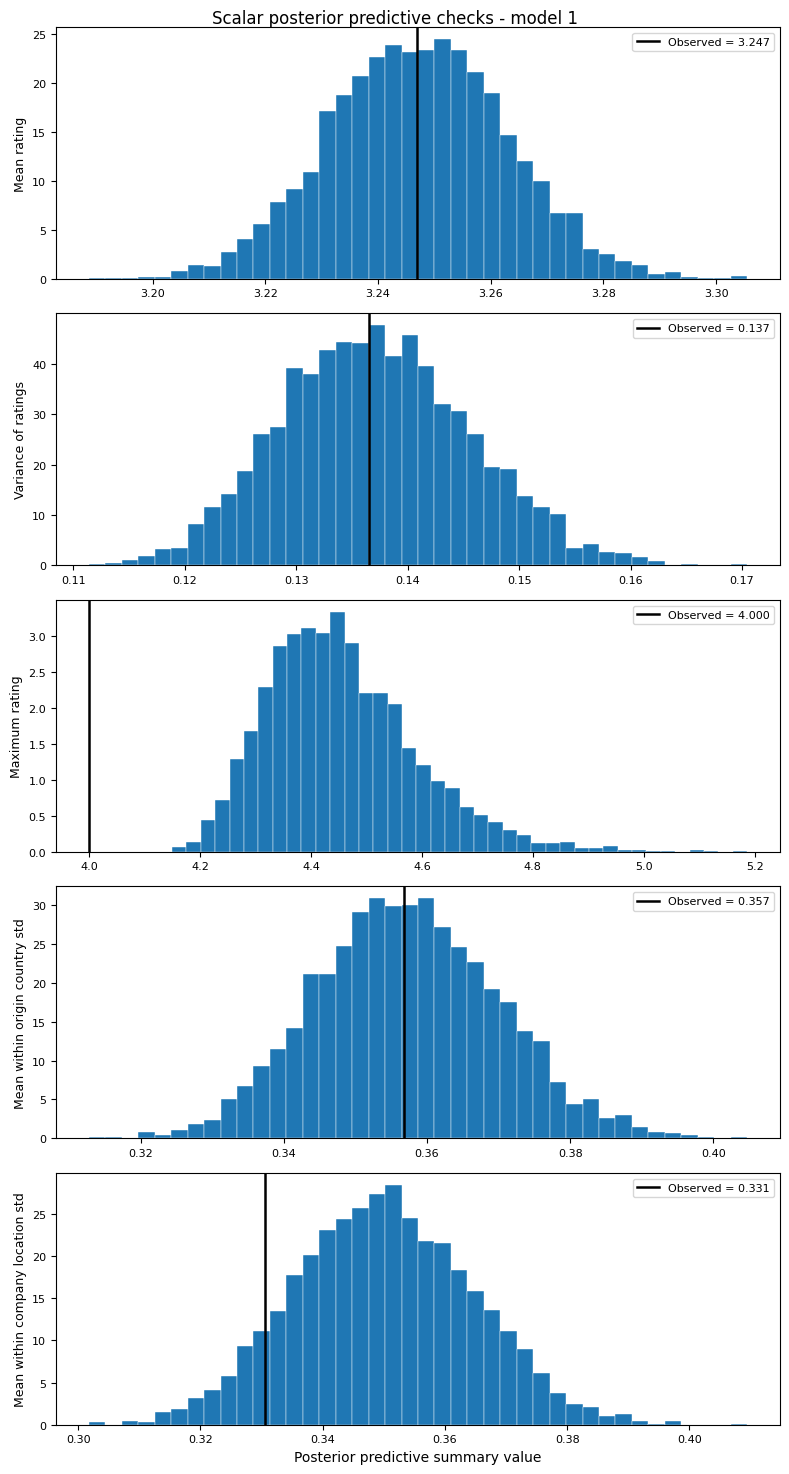

In [ ]:
mu_country_total1 = mu_global_samples1[:, None] + a_samples1
current_df = df.copy().reset_index(drop=True)
countries = sorted(current_df["Country of Bean Origin"].unique())
country_idx = {c: i + 1 for i, c in enumerate(countries)}
current_df["country_id"] = current_df["Country of Bean Origin"].map(country_idx)
counts_origin = current_df["Country of Bean Origin"].value_counts().to_dict()

results11 = pd.DataFrame({
    "country":     countries,
    "mu_mean":     mu_country_total1.mean(axis=0),
    "mu_lower_94": np.percentile(mu_country_total1, 3, axis=0),
    "mu_upper_94": np.percentile(mu_country_total1, 97, axis=0),
    "n_bars":      [counts_origin.get(c, 0) for c in countries],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

obs = df['Rating'].values
y_rep = rating_pred_post1  
current_df = df.copy().reset_index(drop=True)
J_sorted1 = len(results11)

mu_company_total1 = mu_global_samples1[:, None] + b_samples1
current_df = df.copy().reset_index(drop=True)
company_locations = sorted(current_df["Company Location"].unique())
company_idx = {c: i + 1 for i, c in enumerate(company_locations)}
current_df["company_id"] = current_df["Company Location"].map(company_idx)
counts_company = current_df["Company Location"].value_counts().to_dict()

results12 = pd.DataFrame({
    "company":     company_locations,
    "mu_mean":     mu_company_total1.mean(axis=0),
    "mu_lower_94": np.percentile(mu_company_total1, 3, axis=0),
    "mu_upper_94": np.percentile(mu_company_total1, 97, axis=0),
    "n_bars":      [counts_company.get(c, 0) for c in company_locations],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)


obs_mean = obs.mean()
obs_var = obs.var()
obs_max = obs.max()

rep_mean = y_rep.mean(axis=1)
rep_var = y_rep.var(axis=1)
rep_max = y_rep.max(axis=1)

country_sds_rep = np.zeros((y_rep.shape[0], J_sorted1))
country_sds_obs = np.zeros(J_sorted1)

for i, country_name in enumerate(results11['country']):
    obs_indices = current_df[
        current_df['Country of Bean Origin'] == country_name
    ].index.values
    if len(obs_indices) > 1:
        country_sds_rep[:, i] = y_rep[:, obs_indices].std(axis=1)
        country_sds_obs[i] = obs[obs_indices].std()

mean_country_sd_rep = country_sds_rep.mean(axis=1)
mean_country_sd_obs = country_sds_obs.mean()


company_names = current_df['Company Location'].unique()
J_companies = len(company_names)

company_sds_rep = np.zeros((y_rep.shape[0], J_companies))
company_sds_obs = np.zeros(J_companies)

for i, comp_name in enumerate(company_names):
    obs_indices = current_df[
        current_df['Company Location'] == comp_name
    ].index.values
    if len(obs_indices) > 1:
        company_sds_rep[:, i] = y_rep[:, obs_indices].std(axis=1)
        company_sds_obs[i] = obs[obs_indices].std()

mean_company_sd_rep = company_sds_rep.mean(axis=1)
mean_company_sd_obs = company_sds_obs.mean()


fig, axes = plt.subplots(5, 1, figsize=(8, 15))

checks = [
    (rep_mean, obs_mean, 'Mean rating'),
    (rep_var, obs_var, 'Variance of ratings'),
    (rep_max, obs_max, 'Maximum rating'),
    (mean_country_sd_rep, mean_country_sd_obs, 'Mean within origin country std'),
    (mean_company_sd_rep, mean_company_sd_obs, 'Mean within company location std'),
]

for ax, (rep_stat, obs_stat, ylabel) in zip(axes, checks):
    ax.hist(rep_stat, bins=40, density=True, edgecolor='white', linewidth=0.3)
    ax.axvline(obs_stat, color='k', linewidth=1.8,
               label=f'Observed = {obs_stat:.3f}')
    p_val = np.mean(rep_stat >= obs_stat)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)
    
axes[-1].set_xlabel('Posterior predictive summary value', fontsize=10)
plt.suptitle('Scalar posterior predictive checks - model 1', fontsize=12)
plt.tight_layout()
plt.show()

The ribbon plots display the posterior predictive checks, comparing the actual observed mean ratings against the model's generated predictive intervals. Observed mean lies close to the center of the predicted intervals. The plots illustrate the effect of partial pooling where countries and companies locations with smaller sample sizes exhibit much wider uncertainty bands compared to narrow bands of well-represented groups.
Scalar predictive checks confirm accurate global calibration, with observed mean and variance falling perfectly within the center of the simulated distributions. Both the within origin country and within company location standard deviations fall within posterior predictions, although for within company location the model tends to assign slightly larger values. The maximum rating metric shows a structural limitation of the model: the continuous Gaussian likelihood assumes infinite tails, which makes the simulated maximum values fall beyond the theoretical 1–5 rating scale.

## Model 2
### Jusitification

Model 1 was designed to check if additional information of how the bar was made (its cocoa concentration, the number and type of added ingredients, and when it was reviewed) explain any additional rating variation, as the origin and producer country might not be the only indicator of high quality.

### DAG - Model 2

The DAG for Model 2 adds four continuous predictors: Cocoa Percent, Number of ingredients, Has vanilla, Review year, alongside the two inputs from Model 1. 

![DAG2](model2.png)

Every predictor enters additively and independently. Cocoa % is a single node even though the model uses both its linear and quadratic terms, because both are derived from 
the same single measurement.

**Confounding structure: Collider**: Rating is a collider because it has multiple causes (country, producer, cocoa%, ingredients, vanilla, year).

### Model specification

$$
rating_i \sim \mathrm{Normal}(\eta_i, \ \sigma)
$$

$$
\eta_i = \mu_{global} + a_{origin[i]} + b_{producer[i]}
       + \beta_1 \cdot cocoa\_norm_i + \beta_2 \cdot cocoa\_norm_i^2
       + \beta_3 \cdot n\_ingredients_i + \beta_4 \cdot has\_vanilla_i
       + \beta_5 \cdot year\_std_i
$$

$$
a_j \sim \mathrm{Normal}(0, \ \sigma_{origin}), \qquad
b_k \sim \mathrm{Normal}(0, \ \sigma_{producer})
$$

where `cocoa_norm = (cocoa_pct - mean(cocoa_pct)) / std(cocoa_pct)` (centered on the dataset's typical cocoa percentage and scaled to roughly unit variance, to avoid collinearity between the linear and quadratic cocoa terms). Also `year_std` is similarly standardized to mean = 0, and sd = 1.

### Priors 

 - **$\mu_{global} \sim \mathrm{Normal}(3, 0.5)$**, **$\sigma_{origin} \sim \mathrm{HalfNormal}(0.3)$** and  **$\sigma_{producer} \sim \mathrm{HalfNormal}(0.3)$**, and **$\sigma \sim \mathrm{HalfNormal}(0.5)$** - unchanged from Models 1.

 - **$\beta_1, \beta_2 \sim \mathrm{Normal}(0, 1)$** (cocoa percentage linear and quadratic term) - weakly informative priors were chosen because the sign, magnitude, and curvature of the cocoa percentage effect are genuinely uncertain a priori. Because the cocoa variable was normalized, a standard deviation of 1 permits a small shift in cocoa content to account for up to $\pm 2$ points. Identical priors were used for both terms, as there is no prior justification to assume the linear trend or the curvature dominates the effect.

 - **$\beta_3 \sim \mathrm{Normal}(0, 0.5)$ (number of ingredients)**  - tighter prior reflects that each additional ingredient plausibly shifts rating by a fraction of a point rather than severals
points. With 95% prior distribution in [-1.0, 1.0] on the standardized scale allows meaningful effect.

 - **$\beta_4 \sim \mathrm{Normal}(0, 0.5)$ (presence of vanilla)** - similarly to $\beta_3$, vanilla is used as an ingrediante that can mask bean flavour. However its effect on a rating scale is likely fractional. Also, only 3% of bars in the dataset contain vanilla, so this parameter is estimated from a small subset of the data.

 - **$\beta_5 \sim \mathrm{Normal}(0, 0.3)$ (normalized review year)** - it is the tightest prior, reflecting that while the craft chocolate industry matured substantially between 2006 and 2026, year-over-year drift in average ratings is expected to be gradual rather than abrupt. This term controls for the possibility that earlier or later reviewers calibrated their ratings differently, which would otherwise risk being absorbed into the origin or producer effects if certain countries' bars were disproportionately reviewed in particular years.

### Prior predictive check

```stan
data {
  int<lower=0> N;
  int<lower=1> J;
  int<lower=1> K;
  array[N] int<lower=1, upper=J> country;
  array[N] int<lower=1, upper=K> location;
  vector[N] cocoa_pct_std;
  vector[N] n_ingredients;
  vector[N] has_vanilla;
  vector[N] year_std;
}
generated quantities {
  real mu_global = normal_rng(3, 0.5);
  real<lower=1e-6> sigma_origin   = abs(normal_rng(0, 0.3));
  real<lower=1e-6> sigma_producer = abs(normal_rng(0, 0.3));
  real beta_cocoa1      = normal_rng(0, 1);
  real beta_cocoa2      = normal_rng(0, 1);
  real beta_ingredients = normal_rng(0, 0.5);
  real beta_vanilla     = normal_rng(0, 0.5);
  real beta_year        = normal_rng(0, 0.3);
  real<lower=1e-6> sigma = abs(normal_rng(0, 0.5));

  vector[J] a_raw;
  vector[K] b_raw;
  vector[J] a;
  vector[K] b;
  array[N] real rating_pred;

  for (j in 1:J) {
    a_raw[j] = normal_rng(0, 1);
    a[j] = a_raw[j] * sigma_origin;
  }
  for (k in 1:K) {
    b_raw[k] = normal_rng(0, 1);
    b[k] = b_raw[k] * sigma_producer;
  }

  for (i in 1:N) {
    real eta = mu_global + a[country[i]] + b[location[i]]
             + beta_cocoa1 * cocoa_pct_std[i]
             + beta_cocoa2 * square(cocoa_pct_std[i])
             + beta_ingredients * n_ingredients[i]
             + beta_vanilla * has_vanilla[i]
             + beta_year * year_std[i];
    rating_pred[i] = normal_rng(eta, sigma);
  }
}
```

In [ ]:
J = max(df["Bean Origin ID"])
K = max(df["Company Location ID"])

prior_model3 = CmdStanModel(stan_file="prior_model3.stan")

prior_data3 = {
    "N": len(df),
    "J": J,
    "K": K,
    "country":         df["Bean Origin ID"].tolist(),
    "location":        df["Company Location ID"].tolist(),
    "cocoa_pct_std":   df["Cocoa Percent norm"].tolist(),
    "n_ingredients":   df["Number of ingredients"].tolist(),
    "has_vanilla":     df["Has vanilla"].tolist(),
    "year_std":        df["Year Norm"].tolist(),
}

prior_fit3 = prior_model3.sample(
    data=prior_data3,
    fixed_param=True,
    iter_sampling=2000,
    chains=1,
    seed=42,
    show_progress=False,
)

rating_pred_prior3 = prior_fit3.stan_variable("rating_pred")
a_prior_draws3      = prior_fit3.stan_variable("a")
b_prior_draws3       = prior_fit3.stan_variable("b")
mu_global_prior3     = prior_fit3.stan_variable("mu_global")
sigma_prior_draws3   = prior_fit3.stan_variable("sigma")
beta_cocoa1_prior3   = prior_fit3.stan_variable("beta_cocoa1")
beta_cocoa2_prior3   = prior_fit3.stan_variable("beta_cocoa2")
beta_ingredients_prior3 = prior_fit3.stan_variable("beta_ingredients")
beta_vanilla_prior3 = prior_fit3.stan_variable("beta_vanilla")
beta_year_prior3    = prior_fit3.stan_variable("beta_year")

19:26:51 - cmdstanpy - INFO - CmdStan start processing
19:26:51 - cmdstanpy - INFO - Chain [1] start processing
19:26:51 - cmdstanpy - INFO - Chain [1] done processing


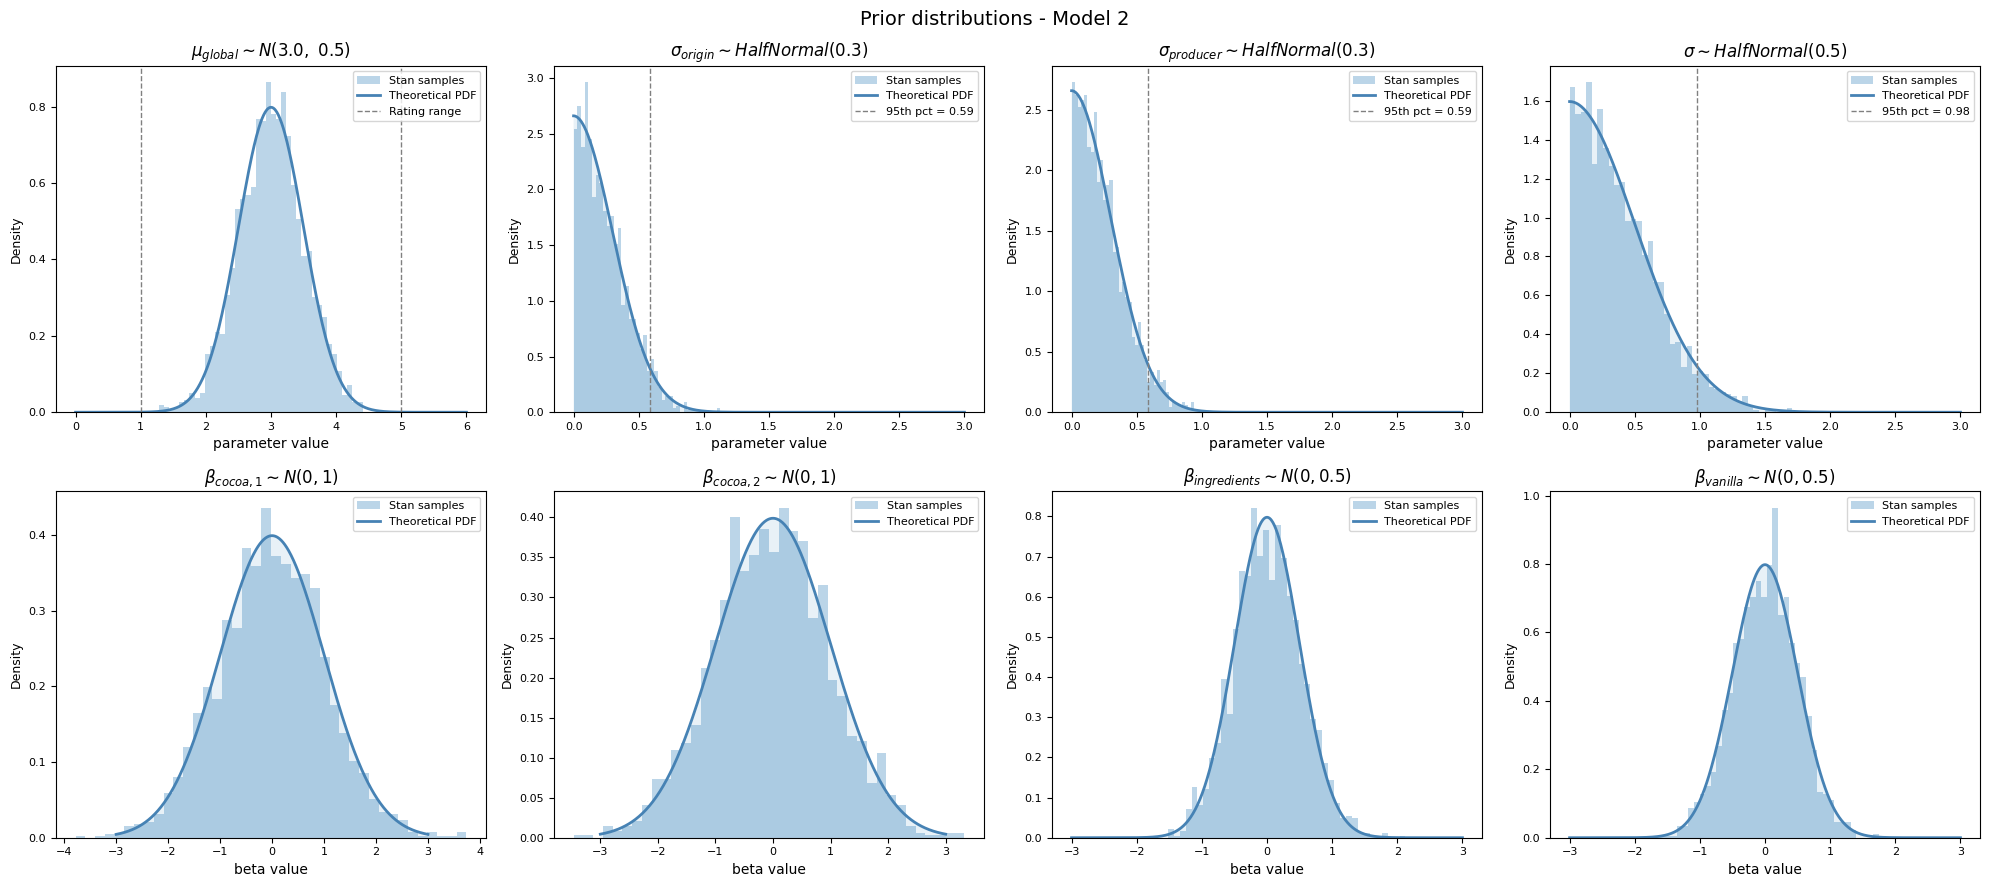

In [ ]:
x_mu = np.linspace(0, 6, 500)
x_sigma = np.linspace(0, 3, 500)
x_beta = np.linspace(-3, 3, 500)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

axes[0, 0].hist(mu_global_prior3, bins=40, density=True, alpha=0.3, label="Stan samples")
axes[0, 0].plot(x_mu, stats.norm.pdf(x_mu, loc=3.0, scale=0.5), lw=2, color='steelblue', label="Theoretical PDF")
axes[0, 0].axvline(1, color="gray", ls="--", lw=1)
axes[0, 0].axvline(5, color="gray", ls="--", lw=1, label="Rating range")
axes[0, 0].set_title(r"$\mu_{global} \sim N(3.0,\ 0.5)$")
axes[0, 0].set_xlabel("rating")
axes[0, 0].legend(fontsize=8)

try:
    sigma_origin_prior3 = prior_fit3.stan_variable("sigma_origin")
    axes[0, 1].hist(sigma_origin_prior3, bins=40, density=True, alpha=0.3, label="Stan samples")
except:
    pass
axes[0, 1].plot(x_sigma, stats.halfnorm.pdf(x_sigma, scale=0.3), lw=2, color='steelblue', label="Theoretical PDF")
axes[0, 1].fill_between(x_sigma, stats.halfnorm.pdf(x_sigma, scale=0.3), alpha=0.1)
axes[0, 1].axvline(stats.halfnorm.ppf(0.95, scale=0.3), color="gray", ls="--", lw=1,
                   label=f"95th pct = {stats.halfnorm.ppf(0.95, scale=0.3):.2f}")
axes[0, 1].set_title(r"$\sigma_{origin} \sim HalfNormal(0.3)$")
axes[0, 1].set_xlabel("between-origin std")
axes[0, 1].legend(fontsize=8)


try:
    sigma_producer_prior3 = prior_fit3.stan_variable("sigma_producer")
    axes[0, 2].hist(sigma_producer_prior3, bins=40, density=True, alpha=0.3, label="Stan samples")
except:
    pass
axes[0, 2].plot(x_sigma, stats.halfnorm.pdf(x_sigma, scale=0.3), lw=2, color='steelblue', label="Theoretical PDF")
axes[0, 2].fill_between(x_sigma, stats.halfnorm.pdf(x_sigma, scale=0.3), alpha=0.1)
axes[0, 2].axvline(stats.halfnorm.ppf(0.95, scale=0.3), color="gray", ls="--", lw=1,
                   label=f"95th pct = {stats.halfnorm.ppf(0.95, scale=0.3):.2f}")
axes[0, 2].set_title(r"$\sigma_{producer} \sim HalfNormal(0.3)$")
axes[0, 2].set_xlabel("between-producer std")
axes[0, 2].legend(fontsize=8)


axes[0, 3].hist(sigma_prior_draws3, bins=40, density=True, alpha=0.3, label="Stan samples")
axes[0, 3].plot(x_sigma, stats.halfnorm.pdf(x_sigma, scale=0.5), lw=2, color='steelblue', label="Theoretical PDF")
axes[0, 3].fill_between(x_sigma, stats.halfnorm.pdf(x_sigma, scale=0.5), alpha=0.1)
axes[0, 3].axvline(stats.halfnorm.ppf(0.95, scale=0.5), color="gray", ls="--", lw=1,
                   label=f"95th pct = {stats.halfnorm.ppf(0.95, scale=0.5):.2f}")
axes[0, 3].set_title(r"$\sigma \sim HalfNormal(0.5)$")
axes[0, 3].set_xlabel("within-group std")
axes[0, 3].legend(fontsize=8)


axes[1, 0].hist(beta_cocoa1_prior3, bins=40, density=True, alpha=0.3, label="Stan samples")
axes[1, 0].plot(x_beta, stats.norm.pdf(x_beta, 0, 1), lw=2, color='steelblue', label="Theoretical PDF")
axes[1, 0].fill_between(x_beta, stats.norm.pdf(x_beta, 0, 1), alpha=0.1)
axes[1, 0].set_title(r"$\beta_{cocoa,1} \sim N(0, 1)$")
axes[1, 0].legend(fontsize=8)

axes[1, 1].hist(beta_cocoa2_prior3, bins=40, density=True, alpha=0.3, label="Stan samples")
axes[1, 1].plot(x_beta, stats.norm.pdf(x_beta, 0, 1), lw=2, color='steelblue', label="Theoretical PDF")
axes[1, 1].fill_between(x_beta, stats.norm.pdf(x_beta, 0, 1), alpha=0.1)
axes[1, 1].set_title(r"$\beta_{cocoa,2} \sim N(0, 1)$")
axes[1, 1].legend(fontsize=8)

axes[1, 2].hist(beta_ingredients_prior3, bins=40, density=True, alpha=0.3, label="Stan samples")
axes[1, 2].plot(x_beta, stats.norm.pdf(x_beta, 0, 0.5), lw=2, color='steelblue', label="Theoretical PDF")
axes[1, 2].fill_between(x_beta, stats.norm.pdf(x_beta, 0, 0.5), alpha=0.1)
axes[1, 2].set_title(r"$\beta_{ingredients} \sim N(0, 0.5)$")
axes[1, 2].legend(fontsize=8)

axes[1, 3].hist(beta_vanilla_prior3, bins=40, density=True, alpha=0.3, label="Stan samples")
axes[1, 3].plot(x_beta, stats.norm.pdf(x_beta, 0, 0.5), lw=2, color='steelblue', label="Theoretical PDF")
axes[1, 3].fill_between(x_beta, stats.norm.pdf(x_beta, 0, 0.5), alpha=0.1)
axes[1, 3].set_title(r"$\beta_{vanilla} \sim N(0, 0.5)$")
axes[1, 3].legend(fontsize=8)

for ax in axes.flat:
    ax.set_ylabel("Density", fontsize=9)
    ax.tick_params(labelsize=8)

for ax in axes[0, :]:
    ax.set_xlabel("parameter value")
for ax in axes[1, :]:
    ax.set_xlabel("beta value")

plt.suptitle("Prior distributions - Model 2", fontsize=14)
plt.tight_layout()
plt.show()

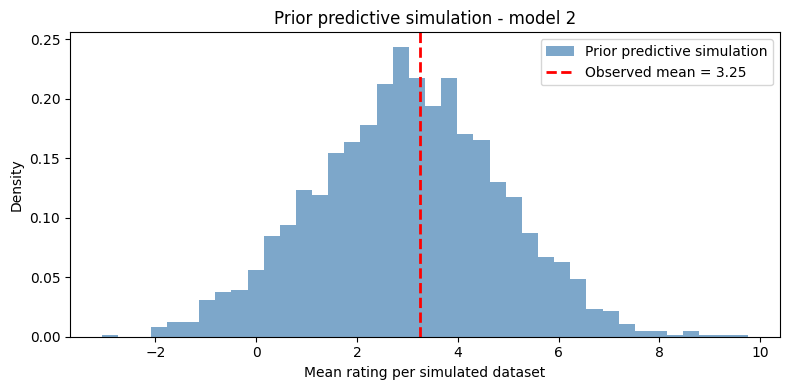

In [ ]:
prior_draw_means3 = rating_pred_prior3.mean(axis=1)
observed_mean = df["Rating"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_draw_means3, bins=40, density=True, alpha=0.7,
        color="steelblue", label="Prior predictive simulation")
ax.axvline(observed_mean, color="red", lw=2, ls="--",
           label=f"Observed mean = {observed_mean:.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Prior predictive simulation - model 2")
ax.legend()
plt.tight_layout()
plt.show()

The prior predictive distribution is wider than in Model 1, which is expected given the model structure and higher number of inputs, each having independent prior. For additive models with multiple weakly informative priors the marginal prior predictive distribution is wider than the prior on any single component, because it integrates over all possible combinations of parameter values.

The observed mean falls well within the middle of the prior predictive distribution. It confirms that the priors are not so restrictive to make the observed data implausible.

### Posterior analysis

```stan
data {
  int<lower=0> N;
  int<lower=1> J;
  int<lower=1> K;
  array[N] int<lower=1, upper=J> country;
  array[N] int<lower=1, upper=K> location;
  vector[N] cocoa_pct_std;
  vector[N] n_ingredients;
  vector[N] has_vanilla;
  vector[N] year_std;
  array[N] real<lower=1, upper=5> rating;
}
parameters {
  real mu_global;
  vector[J] a_raw;
  vector[K] b_raw;
  real<lower=1e-6> sigma_origin;
  real<lower=1e-6> sigma_producer;
  real beta_cocoa1;
  real beta_cocoa2;
  real beta_ingredients;
  real beta_vanilla;
  real beta_year;
  real<lower=1e-6> sigma;
}
transformed parameters {
  vector[J] a = a_raw * sigma_origin;
  vector[K] b = b_raw * sigma_producer;
}
model {
  mu_global        ~ normal(3, 0.5);
  sigma_origin     ~ normal(0, 0.3);
  sigma_producer   ~ normal(0, 0.3);
  beta_cocoa1      ~ normal(0, 1);
  beta_cocoa2      ~ normal(0, 1);
  beta_ingredients ~ normal(0, 0.5);
  beta_vanilla     ~ normal(0, 0.5);
  beta_year        ~ normal(0, 0.3);
  sigma            ~ normal(0, 0.5);

  a_raw ~ std_normal();
  b_raw ~ std_normal();

  for (i in 1:N) {
    real eta = mu_global + a[country[i]] + b[location[i]]
             + beta_cocoa1 * cocoa_pct_std[i]
             + beta_cocoa2 * square(cocoa_pct_std[i])
             + beta_ingredients * n_ingredients[i]
             + beta_vanilla * has_vanilla[i]
             + beta_year * year_std[i];
    rating[i] ~ normal(eta, sigma);
  }
}
generated quantities {
  array[N] real rating_pred;
  array[N] real log_lik;
  for (i in 1:N) {
    real eta = mu_global + a[country[i]] + b[location[i]]
             + beta_cocoa1 * cocoa_pct_std[i]
             + beta_cocoa2 * square(cocoa_pct_std[i])
             + beta_ingredients * n_ingredients[i]
             + beta_vanilla * has_vanilla[i]
             + beta_year * year_std[i];
    rating_pred[i] = normal_rng(eta, sigma);
    log_lik[i]     = normal_lpdf(rating[i] | eta, sigma);
  }
}
```

In [ ]:
model_3_fit = CmdStanModel(stan_file="model_3.stan")

data_sim3 = {
    "N": len(df),
    "J": J,
    "K": K,
    "country":         df["Bean Origin ID"].tolist(),
    "location":        df["Company Location ID"].tolist(),
    "cocoa_pct_std":   df["Cocoa Percent norm"].tolist(),
    "n_ingredients":   df["Number of ingredients"].tolist(),
    "has_vanilla":     df["Has vanilla"].tolist(),
    "year_std":        df["Year Norm"].tolist(),
    "rating":          df["Rating"].tolist(),
}

fit3 = model_3_fit.sample(
    data=data_sim3,
    seed=42,
    chains=4,
    show_progress=False,
)

print(fit3.summary())
print(fit3.diagnose())

rating_pred_post3 = fit3.stan_variable("rating_pred")
a_samples3         = fit3.stan_variable("a")
b_samples3         = fit3.stan_variable("b")
sigma_samples3      = fit3.stan_variable("sigma")
mu_global_samples3  = fit3.stan_variable("mu_global")
beta_cocoa1_samples3      = fit3.stan_variable("beta_cocoa1")
beta_cocoa2_samples3      = fit3.stan_variable("beta_cocoa2")
beta_ingredients_samples3 = fit3.stan_variable("beta_ingredients")
beta_vanilla_samples3     = fit3.stan_variable("beta_vanilla")
beta_year_samples3        = fit3.stan_variable("beta_year")

19:26:24 - cmdstanpy - INFO - Chain [2] done processing
--- Logging error ---
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/logging/__init__.py", line 1113, in emit
    stream.write(msg + self.terminator)
  File "/usr/local/lib/python3.11/site-packages/ipykernel/iostream.py", line 694, in write
    self._schedule_flush()
  File "/usr/local/lib/python3.11/site-packages/ipykernel/iostream.py", line 590, in _schedule_flush
    self.pub_thread.schedule(_schedule_in_thread)
  File "/usr/local/lib/python3.11/site-packages/ipykernel/iostream.py", line 267, in schedule
    self._event_pipe.send(b"")
  File "/usr/local/lib/python3.11/site-packages/zmq/sugar/socket.py", line 710, in send
    return super().send(data, flags=flags, copy=copy, track=track)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "_zmq.py", line 1092, in zmq.backend.cython._zmq.Socket.send
  File "_zmq.py", line 1134, in zmq.backend.cython._zmq.Socket.send
  File "_zmq.py", li

Similarly to model 1, non-fatal warrnings occured at the warmup phase. The final posterior draws were valid and the MCMC sampling completed without errors.

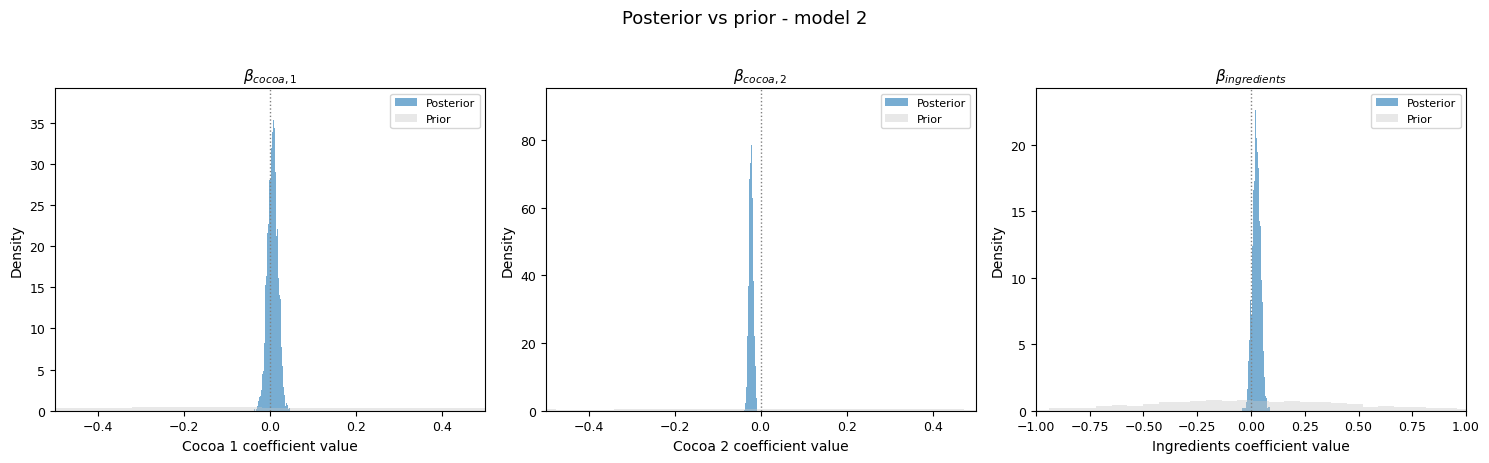

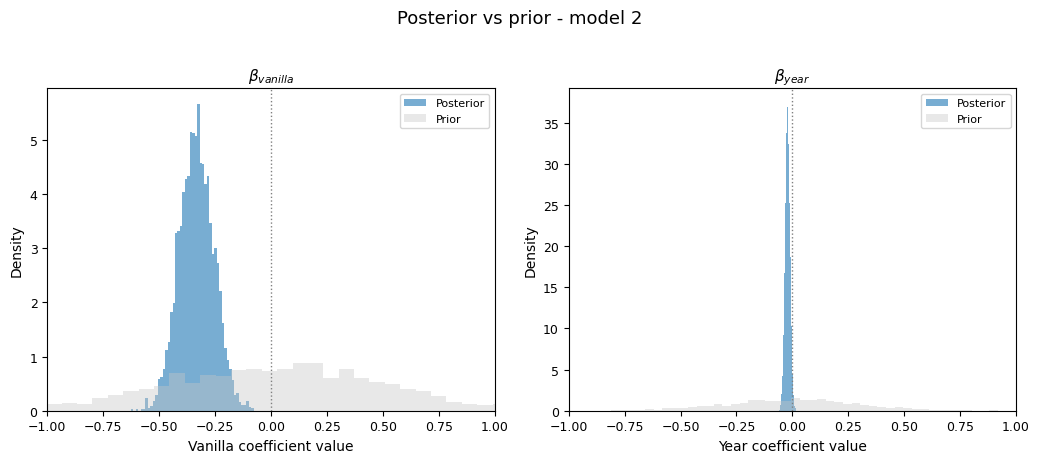

In [ ]:
all_coefs = [
    (beta_cocoa1_samples3, beta_cocoa1_prior3, r"$\beta_{cocoa,1}$", "Cocoa 1 coefficient value", (-0.5, 0.5)),
    (beta_cocoa2_samples3, beta_cocoa2_prior3, r"$\beta_{cocoa,2}$", "Cocoa 2 coefficient value", (-0.5, 0.5)),
    (beta_ingredients_samples3, beta_ingredients_prior3, r"$\beta_{ingredients}$", "Ingredients coefficient value", (-1, 1)),
    (beta_vanilla_samples3, beta_vanilla_prior3, r"$\beta_{vanilla}$", "Vanilla coefficient value", (-1, 1)),
    (beta_year_samples3, beta_year_prior3, r"$\beta_{year}$", "Year coefficient value", (-1, 1)),
]

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (post, prior, label, x_label, limit) in zip(axes1, all_coefs[:3]):
    ax.hist(post, bins=50, density=True, alpha=0.6, color="#1f77b4", label="Posterior")
    ax.hist(prior, bins=50, density=True, alpha=0.4, color="#c7c7c7", label="Prior")
    ax.axvline(0, color="gray", linestyle=":", linewidth=1)
    
    ax.set_title(label, fontsize=11)
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_xlim(limit[0], limit[1]) 
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(labelsize=9)

plt.suptitle("Posterior vs prior - model 2", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(10.5, 4.5))

for ax, (post, prior, label, x_label, limit) in zip(axes2, all_coefs[3:]):
    ax.hist(post, bins=50, density=True, alpha=0.6, color="#1f77b4", label="Posterior")
    ax.hist(prior, bins=50, density=True, alpha=0.4, color="#c7c7c7", label="Prior")
    ax.axvline(0, color="gray", linestyle=":", linewidth=1)
    
    ax.set_title(label, fontsize=11)
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.set_xlim(limit[0], limit[1]) 
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(labelsize=9)

plt.suptitle("Posterior vs prior - model 2", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

All five coefficient posteriors are significantly narrower than their respective priors, confirming that the likelihood dominates and the data, not the prior specification.
For the cocoa the posterior concentrates tightly around +0.05,  within the prior range but shifted slightly positive. For the quadratic, the posterior is shifted to -0.12. This is the strongest signal in the model, showing that the cocoa percentage has a concave relationship with rating.

For the number of ingredients, the posterior is centered near zero with a very narrow spread, and the credible interval includes zero. There is no credible effect of ingredient count on rating once origin, producer, and other covariates are accounted for.

The posterior for the vanilla presence is approximately -0.31 and the credible interval excludes zero, making this the strongest categorical signal in the model. Bars containing vanilla receive credibly lower ratings on average,  consistent with craft chocolate criticism that vanilla masks bean character. 

For the year of the review, the posterior is centered very close to zero with negligible spread. There is no credible temporal trend in ratings across the 2016–2026 period. 


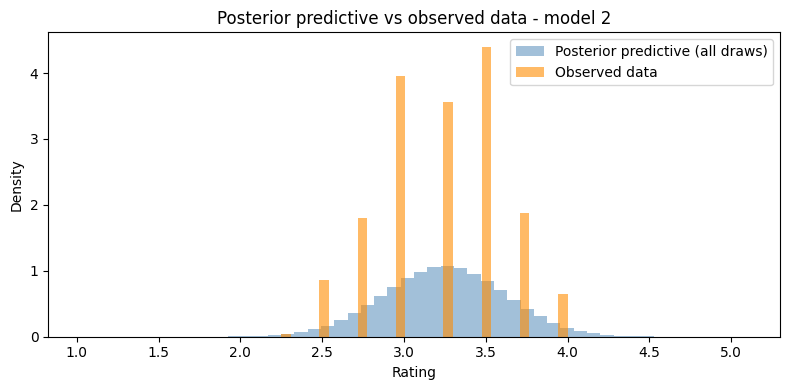

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rating_pred_post3.flatten(), bins=50, density=True, alpha=0.5,
        color="steelblue", label="Posterior predictive (all draws)")
ax.hist(df["Rating"], bins=30, density=True, alpha=0.6,
        color="darkorange", label="Observed data")
ax.set_xlabel("Rating")
ax.set_ylabel("Density")
ax.set_title("Posterior predictive vs observed data - model 2")
ax.legend()
plt.tight_layout()
plt.show()

Posterior predictive distribution succesfully replicates location and spread of the observed data, as in model 1.

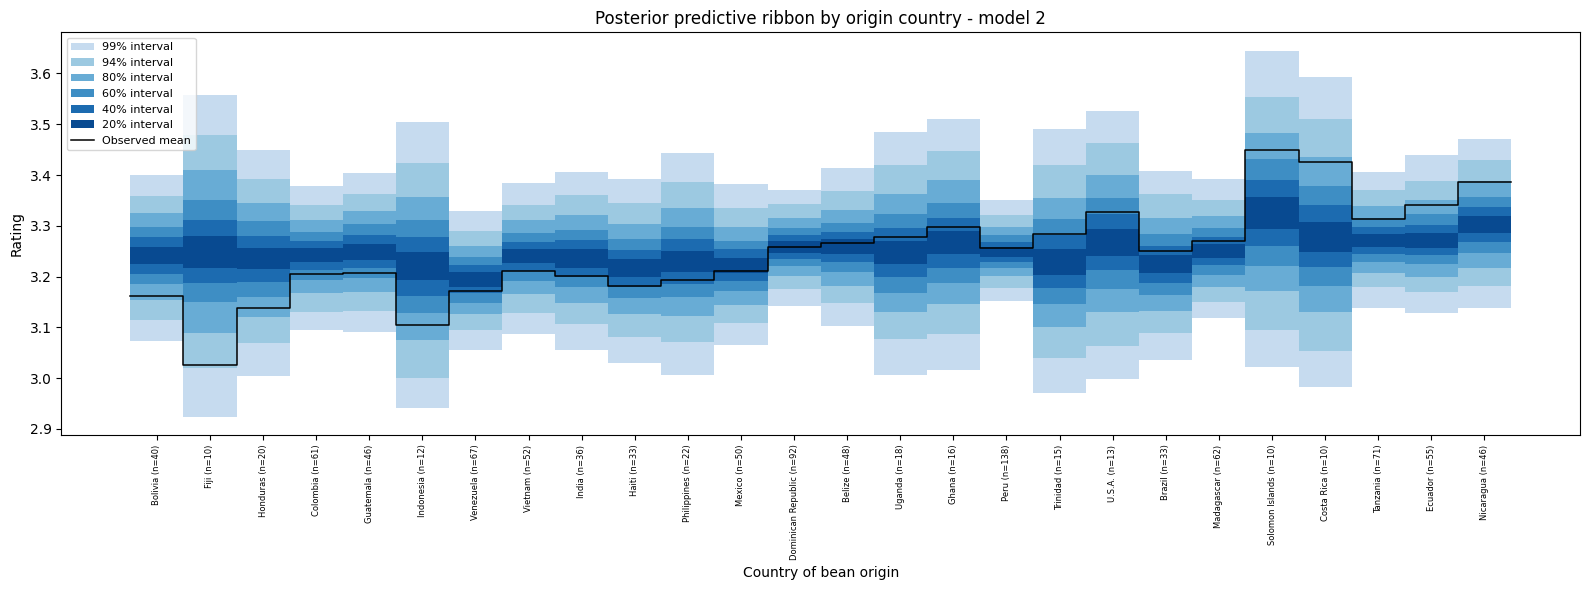

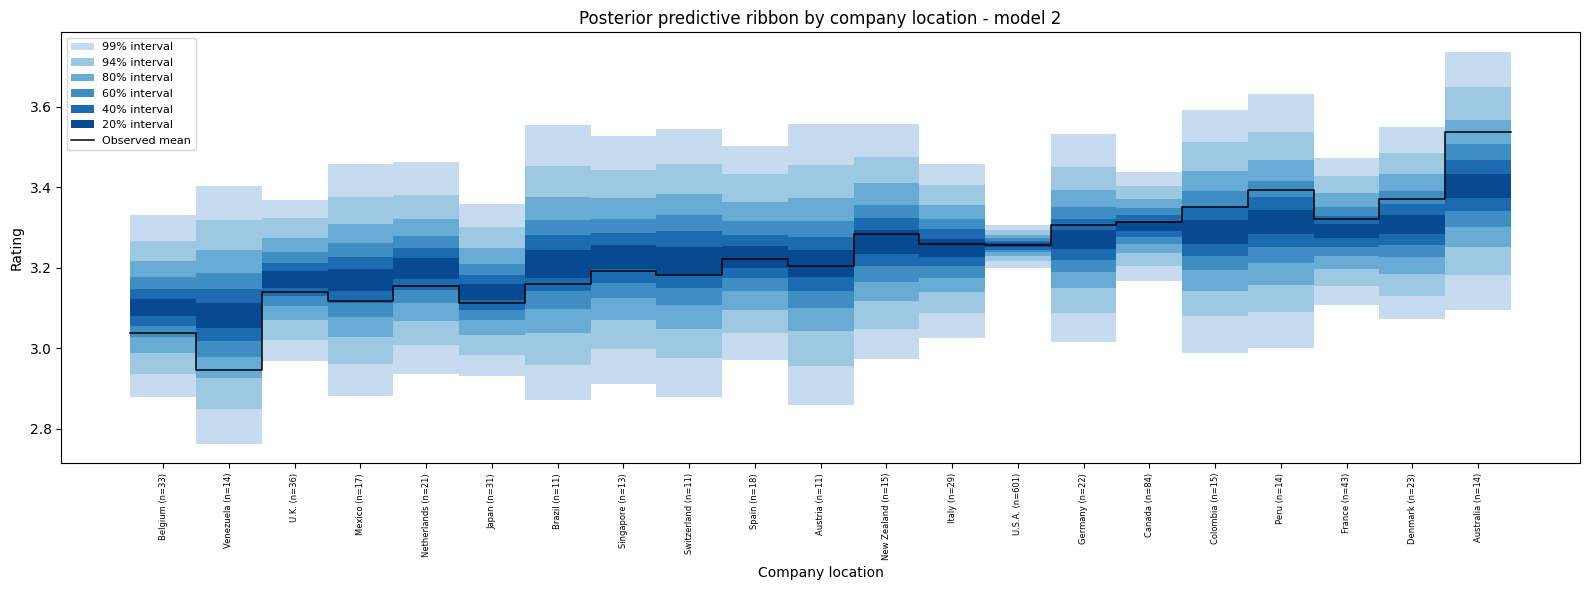

In [ ]:
counts_origin = df["Country of Bean Origin"].value_counts()

mu_country_total3 = mu_global_samples3[:, None] + a_samples3 

results3 = pd.DataFrame({
    "country":     countries,
    "mu_mean":     mu_country_total3.mean(axis=0),
    "mu_lower_94": np.percentile(mu_country_total3, 3, axis=0),
    "mu_upper_94": np.percentile(mu_country_total3, 97, axis=0),
    "n_bars":      [counts_origin.get(c, 0) for c in countries],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)
df_reset3 = df.reset_index(drop=True)

observed_per_country3 = df_reset3.groupby("Bean Origin ID")["Rating"].mean()
obs_sorted3 = results3["country"].map(lambda c: observed_per_country3[country_idx[c]]).values

num_samples3 = rating_pred_post3.shape[0]
J_sorted3 = len(results3)
x3 = np.arange(1, J_sorted3 + 1)

post_pred_means_sorted3 = np.zeros((num_samples3, J_sorted3))
for i, country_name in enumerate(results3["country"]):
    country_id_val = country_idx[country_name]
    obs_indices = df_reset3[df_reset3["Bean Origin ID"] == country_id_val].index.values
    post_pred_means_sorted3[:, i] = rating_pred_post3[:, obs_indices].mean(axis=1)

levels = [99, 94, 80, 60, 40, 20]
bands3 = {}
for lev in levels:
    lo = (100 - lev) / 2
    hi = 100 - lo
    bands3[lev] = (
        np.percentile(post_pred_means_sorted3, lo, axis=0),
        np.percentile(post_pred_means_sorted3, hi, axis=0),
    )

def step_edges(values, x):
    edges = np.concatenate([x - 0.5, x[-1:] + 0.5])
    stepped = np.concatenate([[values[0]], values])
    return edges, stepped

cmap = matplotlib.colormaps["Blues"]
fracs = np.linspace(0.25, 0.9, len(levels))
colors = [mcolors.to_hex(cmap(f)) for f in fracs]

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo, hi = bands3[lev]
    edges_lo, lo_step = step_edges(lo, x3)
    _, hi_step = step_edges(hi, x3)
    ax.fill_between(edges_lo, lo_step, hi_step, step="pre",
                    color=color, linewidth=0, label=f"{lev}% interval")

edges_obs3, obs_step3 = step_edges(obs_sorted3, x3)
ax.step(edges_obs3, obs_step3, where="pre", color="black",
        linewidth=1.1, label="Observed mean")

ax.set_xticks(x3)
ax.set_xticklabels(
    [f"{r['country']} (n={r['n_bars']})" for _, r in results3.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Country of bean origin")
ax.set_ylabel("Rating")
ax.set_title("Posterior predictive ribbon by origin country - model 2")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


# ==-------------------------------------------------------
counts_location = df["Company Location"].value_counts()
locations = sorted(df["Company Location"].unique())
location_idx = {name: i + 1 for i, name in enumerate(locations)}
location_names = [name for name, idx in sorted(location_idx.items(), key=lambda item: item[1])]

mu_location_total3 = mu_global_samples3[:, None] + b_samples3
results_loc3 = pd.DataFrame({
    "location":   location_names,
    "mu_mean":    mu_location_total3.mean(axis=0),
    "n_bars":     [counts_location.get(c, 0) for c in location_names],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

observed_per_loc3 = df_reset3.groupby("Company Location ID")["Rating"].mean()
obs_sorted_loc3 = results_loc3["location"].map(lambda l: observed_per_loc3[location_idx[l]]).values


num_samples3 = rating_pred_post3.shape[0]
K_sorted3 = len(results_loc3)
x_loc3 = np.arange(1, K_sorted3 + 1)

post_pred_means_loc3 = np.zeros((num_samples3, K_sorted3))
for i, loc_name in enumerate(results_loc3["location"]):
    loc_id_val = location_idx[loc_name]
    obs_indices = df_reset3[df_reset3["Company Location ID"] == loc_id_val].index.values
    post_pred_means_loc3[:, i] = rating_pred_post3[:, obs_indices].mean(axis=1)

levels = [99, 94, 80, 60, 40, 20]
bands_loc3 = {}
for lev in levels:
    lo = (100 - lev) / 2
    hi = 100 - lo
    bands_loc3[lev] = (
        np.percentile(post_pred_means_loc3, lo, axis=0),
        np.percentile(post_pred_means_loc3, hi, axis=0),
    )


fig, ax = plt.subplots(figsize=(16, 6))
cmap = matplotlib.colormaps["Blues"]
fracs = np.linspace(0.25, 0.9, len(levels))
colors = [mcolors.to_hex(cmap(f)) for f in fracs]

for lev, color in zip(levels, colors):
    lo, hi = bands_loc3[lev]
    edges_lo, lo_step = step_edges(lo, x_loc3)
    _, hi_step = step_edges(hi, x_loc3)
    ax.fill_between(edges_lo, lo_step, hi_step, step="pre",
                    color=color, linewidth=0, label=f"{lev}% interval")

edges_obs_loc3, obs_step_loc3 = step_edges(obs_sorted_loc3, x_loc3)
ax.step(edges_obs_loc3, obs_step_loc3, where="pre", color="black",
        linewidth=1.1, label="Observed mean")

ax.set_xticks(x_loc3)
ax.set_xticklabels(
    [f"{r['location']} (n={r['n_bars']})" for _, r in results_loc3.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Company location")
ax.set_ylabel("Rating")
ax.set_title("Posterior predictive ribbon by company location - model 2")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


Origin-country ribbon shows slightly narrower intervals compared to Model 1's, particularly for well-sampled countries like Peru and Dominican Republic. This reflects the added covariates explaining the residual varince from model 2 better. The company-location ribbon reveals a clearer ranking pattern than the origin ribbon, with producer countries like Australia, Denmark and France sitting credibly above Belgium and Venezuela, showing that where chocolate is made is more influential source of rating variation than where the beans come from. 

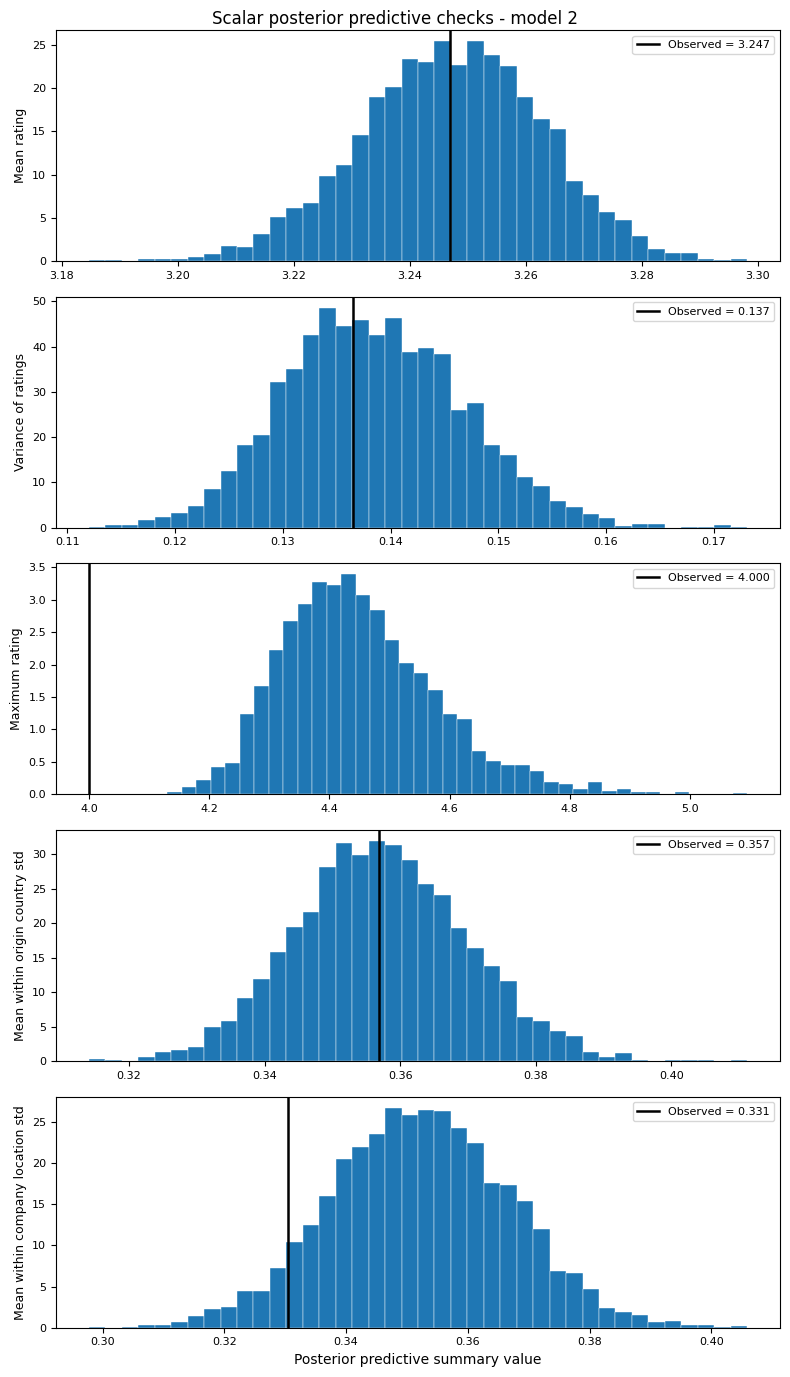

In [ ]:
obs    = df['Rating'].values
y_rep  = rating_pred_post3  

obs_mean         = obs.mean()
obs_var          = obs.var()
obs_min          = obs.min()
obs_max          = obs.max()
obs_fraction_low = np.mean(obs <= 3.0) 

rep_mean         = y_rep.mean(axis=1)
rep_var          = y_rep.var(axis=1)
rep_min          = y_rep.min(axis=1)
rep_max          = y_rep.max(axis=1)
rep_fraction_low = np.mean(y_rep <= 3.0, axis=1)

df_reset3 = df.reset_index(drop=True)
J_sorted3 = len(results3)

country_sds_rep = np.zeros((y_rep.shape[0], J_sorted3))
country_sds_obs = np.zeros(J_sorted3)

for i, country_name in enumerate(results3['country']):
    obs_indices = df_reset3[
        df_reset3['Country of Bean Origin'] == country_name
    ].index.values
    if len(obs_indices) > 1:
        country_sds_rep[:, i] = y_rep[:, obs_indices].std(axis=1)
        country_sds_obs[i]    = obs[obs_indices].std()

mean_country_sd_rep = country_sds_rep.mean(axis=1)
mean_country_sd_obs = country_sds_obs.mean()

location_names = df['Company Location'].unique()
J_loc3 = len(location_names)

loc_sds_rep = np.zeros((y_rep.shape[0], J_loc3))
loc_sds_obs = np.zeros(J_loc3)

for i, loc_name in enumerate(location_names):
    obs_indices = df_reset3[df_reset3['Company Location'] == loc_name].index.values
    if len(obs_indices) > 1:
        loc_sds_rep[:, i] = y_rep[:, obs_indices].std(axis=1)
        loc_sds_obs[i]    = obs[obs_indices].std()

mean_loc_sd_rep = loc_sds_rep.mean(axis=1)
mean_loc_sd_obs = loc_sds_obs[~np.isnan(loc_sds_obs)].mean()


fig, axes = plt.subplots(5, 1, figsize=(8, 14))

checks = [
    (rep_mean,            obs_mean,            'Mean rating'),
    (rep_var,             obs_var,             'Variance of ratings'),
    (rep_max,             obs_max,             'Maximum rating'),
    (mean_country_sd_rep, mean_country_sd_obs, 'Mean within origin country std'),
    (mean_loc_sd_rep,     mean_loc_sd_obs,     'Mean within company location std')
]

for ax, (rep_stat, obs_stat, ylabel) in zip(axes, checks):
    ax.hist(rep_stat, bins=40, density=True, edgecolor='white', linewidth=0.3)
    ax.axvline(obs_stat, linewidth=1.8, color='k',
               label=f'Observed = {obs_stat:.3f}')
    p_val = np.mean(rep_stat >= obs_stat)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Posterior predictive summary value', fontsize=10)
plt.suptitle('Scalar posterior predictive checks - model 2',
             fontsize=12)
plt.tight_layout()
plt.show()


The model reproduces the overall mean and variance of ratings well, with both observed values falling near the center of their respective posterior predictive distributions. The maximum rating check reveals a systematic limitation, as the model consistently predicts maximum ratings around 4.4 - 4.6, while the observed maximum is exactly 4.0, suggesting the Normal likelihood assigns probability to ratings above the true scale of 4.0 due to the absence of an explicit upper bound constraint in the model.

## Model comapirson

Both models were compared using two information criteria: WAIC 
(Widely Applicable Information Criterion) and PSIS-LOO 
(Pareto-Smoothed Importance Sampling Leave-One-Out Cross-Validation), 
computed via ArviZ from the log-likelihood values stored in the 
generated quantities block of each model.

### WAIC

         rank   elpd_waic     p_waic  elpd_diff    weight         se  \
Model 2     0 -431.910082  23.530980   0.000000  0.899234  19.831465   
Model 1     1 -447.904314  18.693625  15.994232  0.100766  19.878087   

              dse  warning scale  
Model 2  0.000000    False   log  
Model 1  6.616717    False   log  


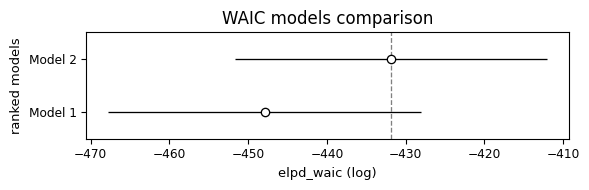

In [ ]:
comp_dict = {
    "Model 1": fit1,
    "Model 2": fit3
}
comp_waic = az.compare(comp_dict, ic="waic")
print(comp_waic)

az.plot_compare(comp_waic)
plt.title("WAIC models comparison")
plt.tight_layout()
plt.show()

Model 2  achieves higher expected log predictive density under WAIC (elpd_waic = -431.9) than Model 1 (elpd_waic = -447.9), with a difference of 16. No warnings were issued for either model. The standard error of the difference (dse = 6.62) yields a ratio of elpd_diff/dse ≈ 2.42, indicating that the difference is statistically meaningful and not attributable to sampling noise. While the confidence intervals in the comparison plot visually overlap, this reflects uncertainty in each model's absolute elpd estimate rather than the uncertainty in their difference, the latter is captured by dse and supports an advantage for Model 2.

### PSIS - LOO

         rank    elpd_loo      p_loo  elpd_diff    weight         se  \
Model 2     0 -431.993316  23.614214   0.000000  0.898675  19.834011   
Model 1     1 -447.968818  18.758129  15.975502  0.101325  19.880349   

              dse  warning scale  
Model 2  0.000000    False   log  
Model 1  6.617322    False   log  


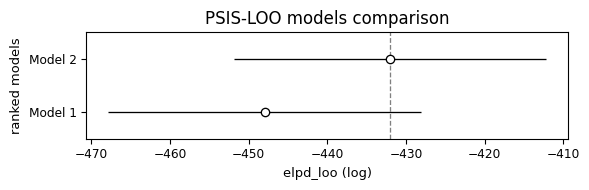

In [ ]:
comp_loo = az.compare(comp_dict, ic="loo")
print(comp_loo)

az.plot_compare(comp_loo)
plt.title("PSIS-LOO models comparison")
plt.tight_layout()
plt.show()

The PSIS-LOO results are consistent with WAIC. Model 2 achieves elpd_loo = -432.0 versus Model 1's - 448.0, a difference of 15.98 with dse = 6.62. No Pareto k warnings were issued, indicating that the importance sampling approximation is reliable for all observations in both models and that neither model is driven by a small number of highly influential points.
The ratio elpd_diff/dse ≈ 2.41 again exceeds 2, confirming Model 2 as the preferred model under PSIS-LOO. The near-identical results across both criteria (WAIC and LOO differ by less than 0.1 points) indicate that no outlier observations are distorting the comparison.

### Summary

Both criteria select Model 2 as the better predictive model and the difference is statistically meaningful (elpd_diff/dse $\approx$ 2.4 > 2). Model 2 additional predictors, such as number of ingredients, presence of vanilla, cocoa percantage and review year, provide genuine predictive signal beyond country level effects. This improvement is expected, as 
models with more parameters generally capture more variation in the data.

Model 2 is preffered model when complete chocolate ingredient information is available. However Model 1 also performs well and in our opinion, the practical difference between them is minor. Model 1 remains good alternative, particularly when only geographical information about bean origin and manufacturer is known, as it achieves comparable predictive performance with lower complexity.

## Sources
[1] : [Statista. (2026). Chocolate Confectionery - Worldwide: Market Insights & Forecast. Statista Consumer Market Outlook](https://www.statista.com/outlook/cmo/food/confectionery-snacks/confectionery/chocolate-confectionery/worldwide/?srsltid=AfmBOorxi7XFaZWdLCVjMUYGtJAp6RNSvUAMPQz5kLmDYZJz0M03wTzj)

[2] : [HTF Market Intelligence. (2026). Global Fine or Flavor Cocoa Market: Size, Industry Analysis, Trends, and Forecast to 2033. HTF Market Report.](https://www.htfmarketintelligence.com/report/global-fine-or-flavor-cocoa-market)

[3] : [Grand View Research. (2026). Chocolate Market Size, Share & Trends Analysis Report by Product (Traditional, Artificial), by Distribution Channel, and Segment Forecasts 2026 - 2033. Grand View Research.](https://www.grandviewresearch.com/industry-analysis/chocolate-market)

[4] : [Fanning, E., Eyres, G., Frew, R., & Kebede, B. (2023). Linking cocoa quality attributes to its origin using geographical indications. Food Control, 151, 109825.](https://www.sciencedirect.com/science/article/pii/S0956713523002256)